In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import find_peaks
from tqdm import tqdm
from itertools import product
from joblib import Parallel, delayed
from matplotlib import rcParams
import seaborn as sns
from scipy.interpolate import griddata
import os
from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks

In [3]:
# Пути к файлам
results_directory = "results"
summary_file_path = os.path.join(results_directory, "simulations_summary.csv")
    
if not os.path.exists(summary_file_path):
    print(f"Файл {summary_file_path} не найден!")
    
summary_tab = pd.read_csv(summary_file_path)
#summary_tab = summary_tab[(summary_tab['df']>0) & (summary_tab['df']<6.2)].copy(deep=True)
print(f"Загружено {len(summary_tab)} записей из сводной таблицы")


Загружено 245 записей из сводной таблицы


In [4]:
summary_tab.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 245 entries, 0 to 244
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            245 non-null    object 
 1   A             245 non-null    float64
 2   df            245 non-null    float64
 3   w             245 non-null    float64
 4   results_file  245 non-null    object 
dtypes: float64(3), object(2)
memory usage: 9.7+ KB


In [5]:
summary_tab.iloc[0]['A']

np.float64(0.1)

In [6]:
summary_tab.head()

,id,A,df,w,results_file
0,a24d0aab-83f7-46b9-b4e1-f69d44ebd266,0.1,0.1,0.700004,sim_a24d0aab-83f7-46b9-b4e1-f69d44ebd266.npz
1,b69ce96b-e3ed-49ed-a8d6-902af30b81a7,0.1,0.1,2.333348,sim_b69ce96b-e3ed-49ed-a8d6-902af30b81a7.npz
2,5c914f53-16af-4bf6-9598-2405a03667c4,0.1,0.1,3.966692,sim_5c914f53-16af-4bf6-9598-2405a03667c4.npz
3,a0f92571-810d-4007-8940-27100bd1124f,0.1,0.1,5.600035,sim_a0f92571-810d-4007-8940-27100bd1124f.npz
4,73272132-b8ca-4803-8e80-3d9c15f205c3,0.1,0.1,7.233379,sim_73272132-b8ca-4803-8e80-3d9c15f205c3.npz


In [7]:
# Уникальные значения разностей фазы
DF = summary_tab['df'].unique()
print('Разности фазы(rad):', DF)

# Уникальные значения частот возбуждающего сигнала
Freqs = summary_tab['w'].unique()
print('Частоты(Hz):', Freqs)

# Уникальные значения амплитуд
Ampls = summary_tab['A'].unique()
print('Амплитуды(N):', Ampls)

# Значения duty для управляющего меандра
#Duty = summary_tab['duty'].unique()
#print('duty(%):', Duty)

Разности фазы(rad): [0.1        1.11386422 2.12772844 3.14159265 4.15545687 5.16932109
 6.18318531]
Частоты(Hz): [ 0.70000441  2.33334803  3.96669165  5.60003527  7.23337889  8.86672252
 10.50006614]
Амплитуды(N): [0.1  0.15 0.2  0.25 0.3 ]


# построить диаграмму пиков в зависимости от амплитуды силы и частоты


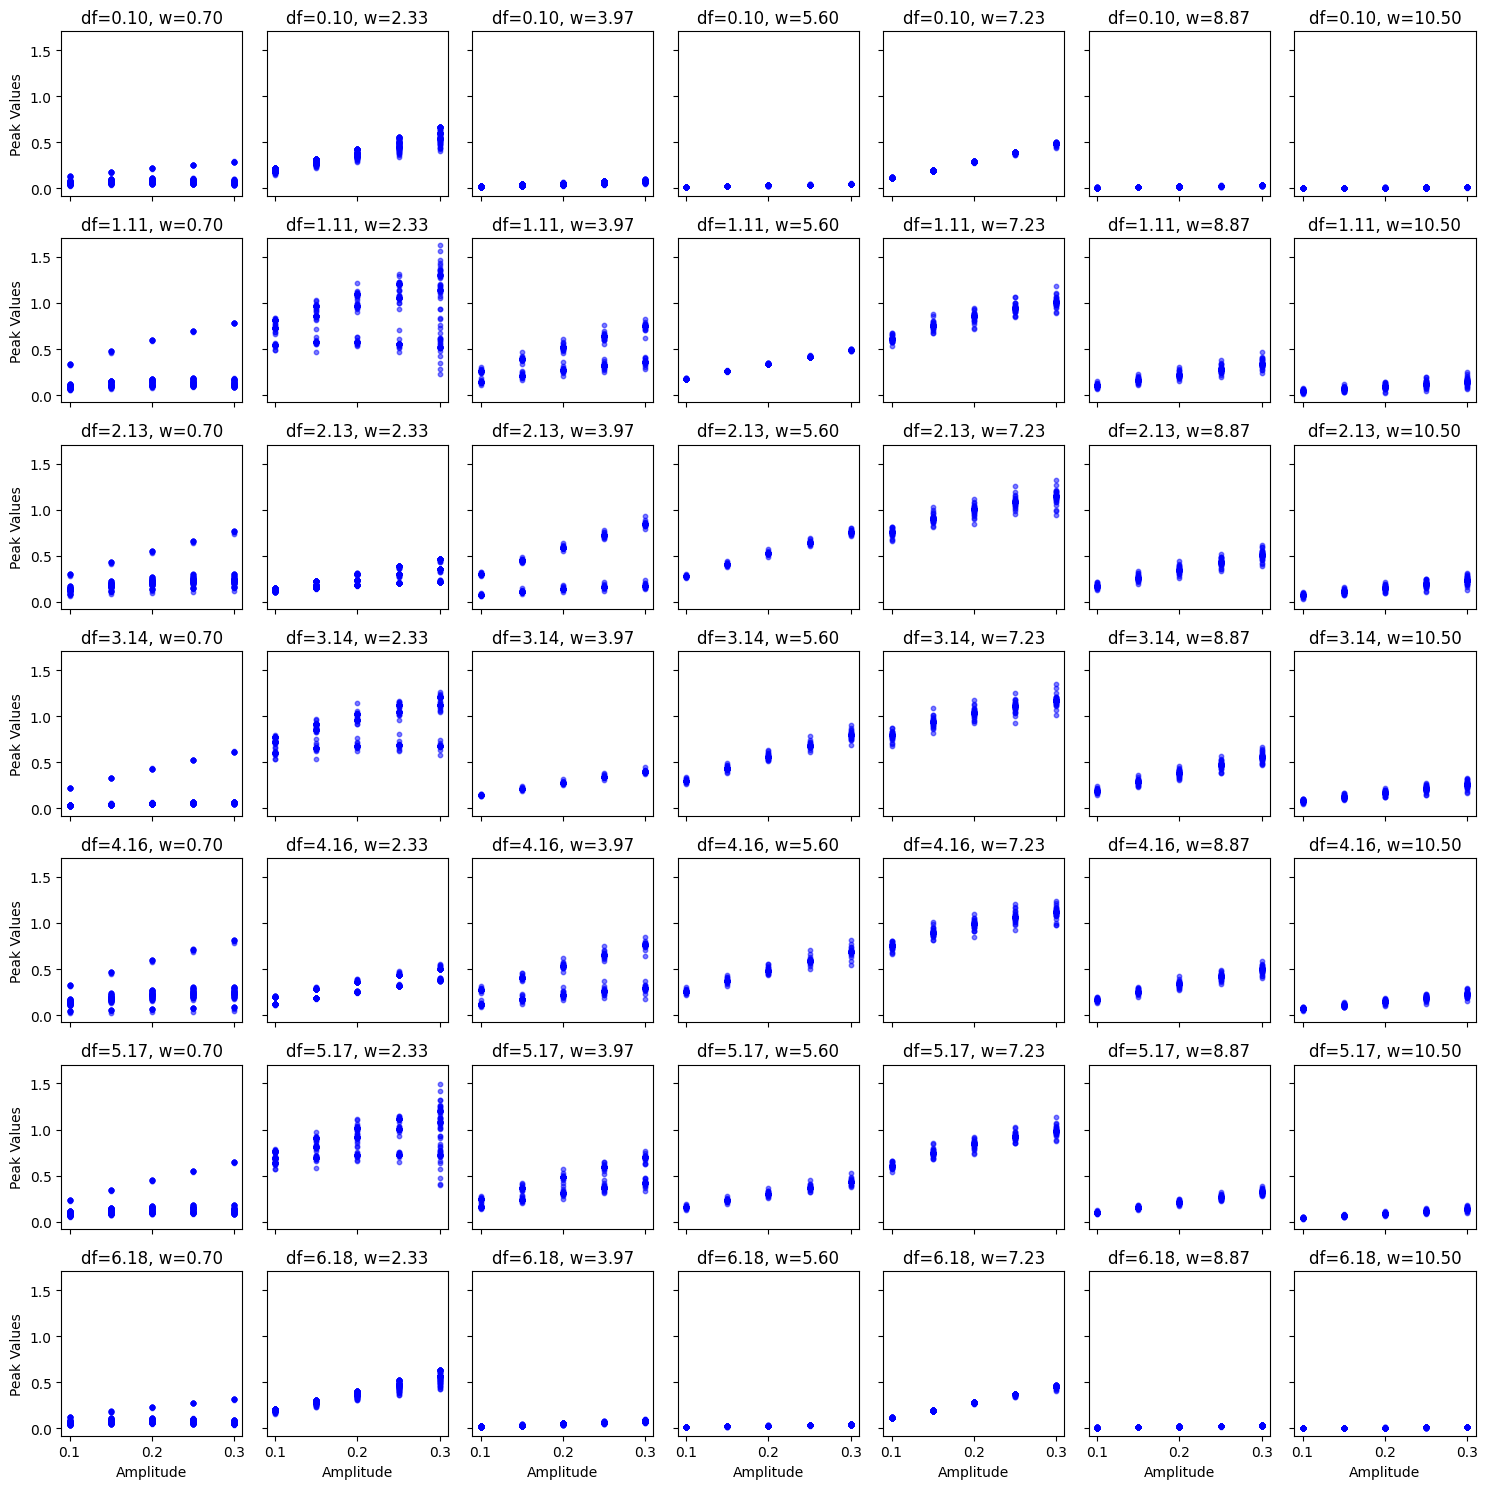

In [8]:
def plot_faceted_peak_diagram(summary_tab, results_dir="results"):
    fig, axes = plt.subplots(len(DF), len(Freqs), figsize=(15, 15), sharex=True, sharey=True)
    
    if len(DF) == 1 or len(Freqs) == 1:
        axes = np.array(axes).reshape(len(DF), len(Freqs))
    
    for i, df in enumerate(DF):
        for j, freq in enumerate(Freqs):
            fixed_tab = summary_tab[(summary_tab['df'] == df) & (summary_tab['w'] == freq)]
            
            for _, row in fixed_tab.iterrows():
                data = np.load(os.path.join(results_dir, row['results_file']))
                Q = data['Q']
                T = data['T']
                
                mask = T > 15 * 1000
                Q = Q[mask]-np.pi/2
                T = T[mask]
                
                peaks, _ = find_peaks(Q, height=0)
                q_peaks = Q[peaks]
                
                axes[i, j].scatter([row['A']] * len(q_peaks), q_peaks,
                                 c='blue', alpha=0.5, s=10)
            
            axes[i, j].set_title(f'df={df:.2f}, w={freq:.2f}')
            if i == len(DF) - 1:
                axes[i, j].set_xlabel('Amplitude')
            if j == 0:
                axes[i, j].set_ylabel('Peak Values')
    
    plt.tight_layout()
    plt.show()

plot_faceted_peak_diagram(summary_tab, results_dir="results")

# Анализ фазовых траекторий
## Визуализация временных рядов

Динамика угла для A=0.1


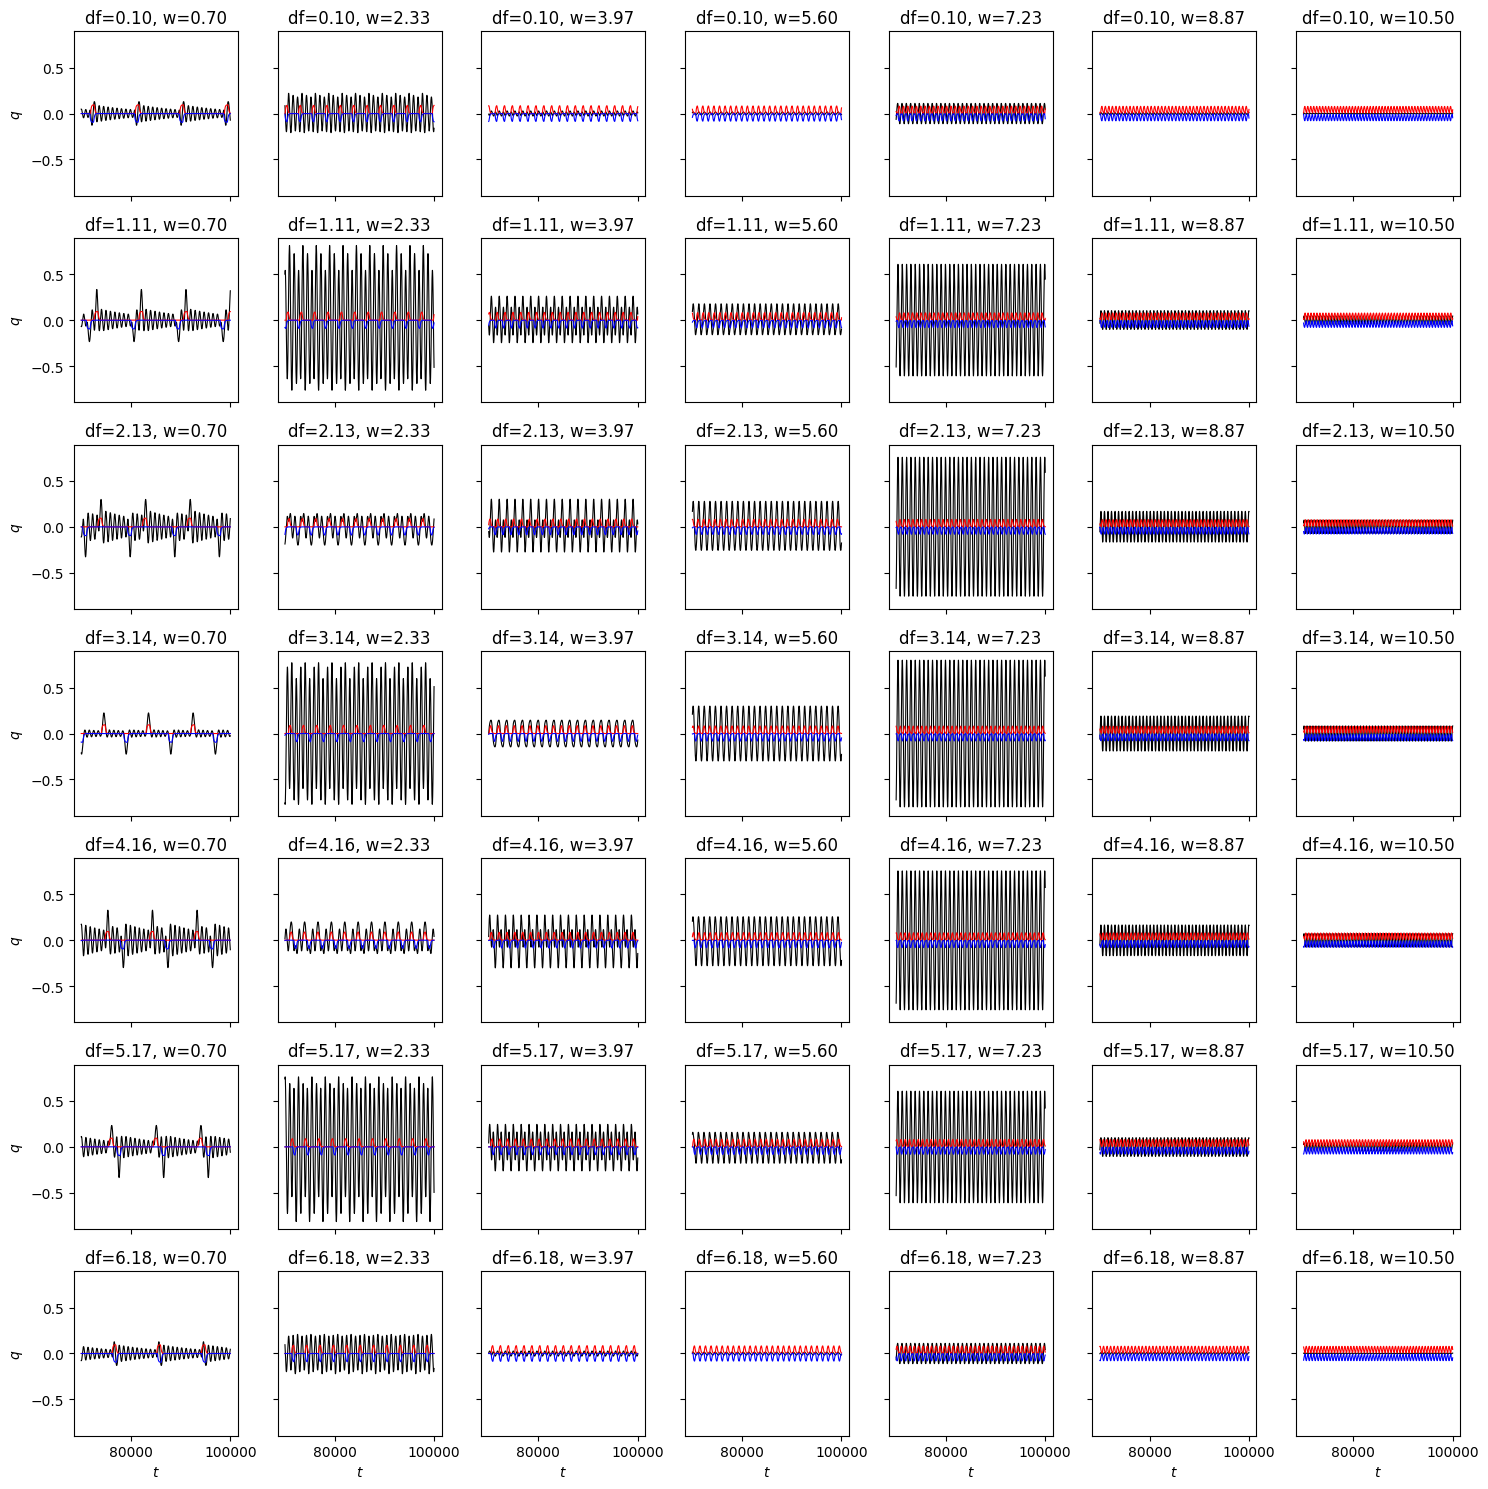

Динамика угла для A=0.15


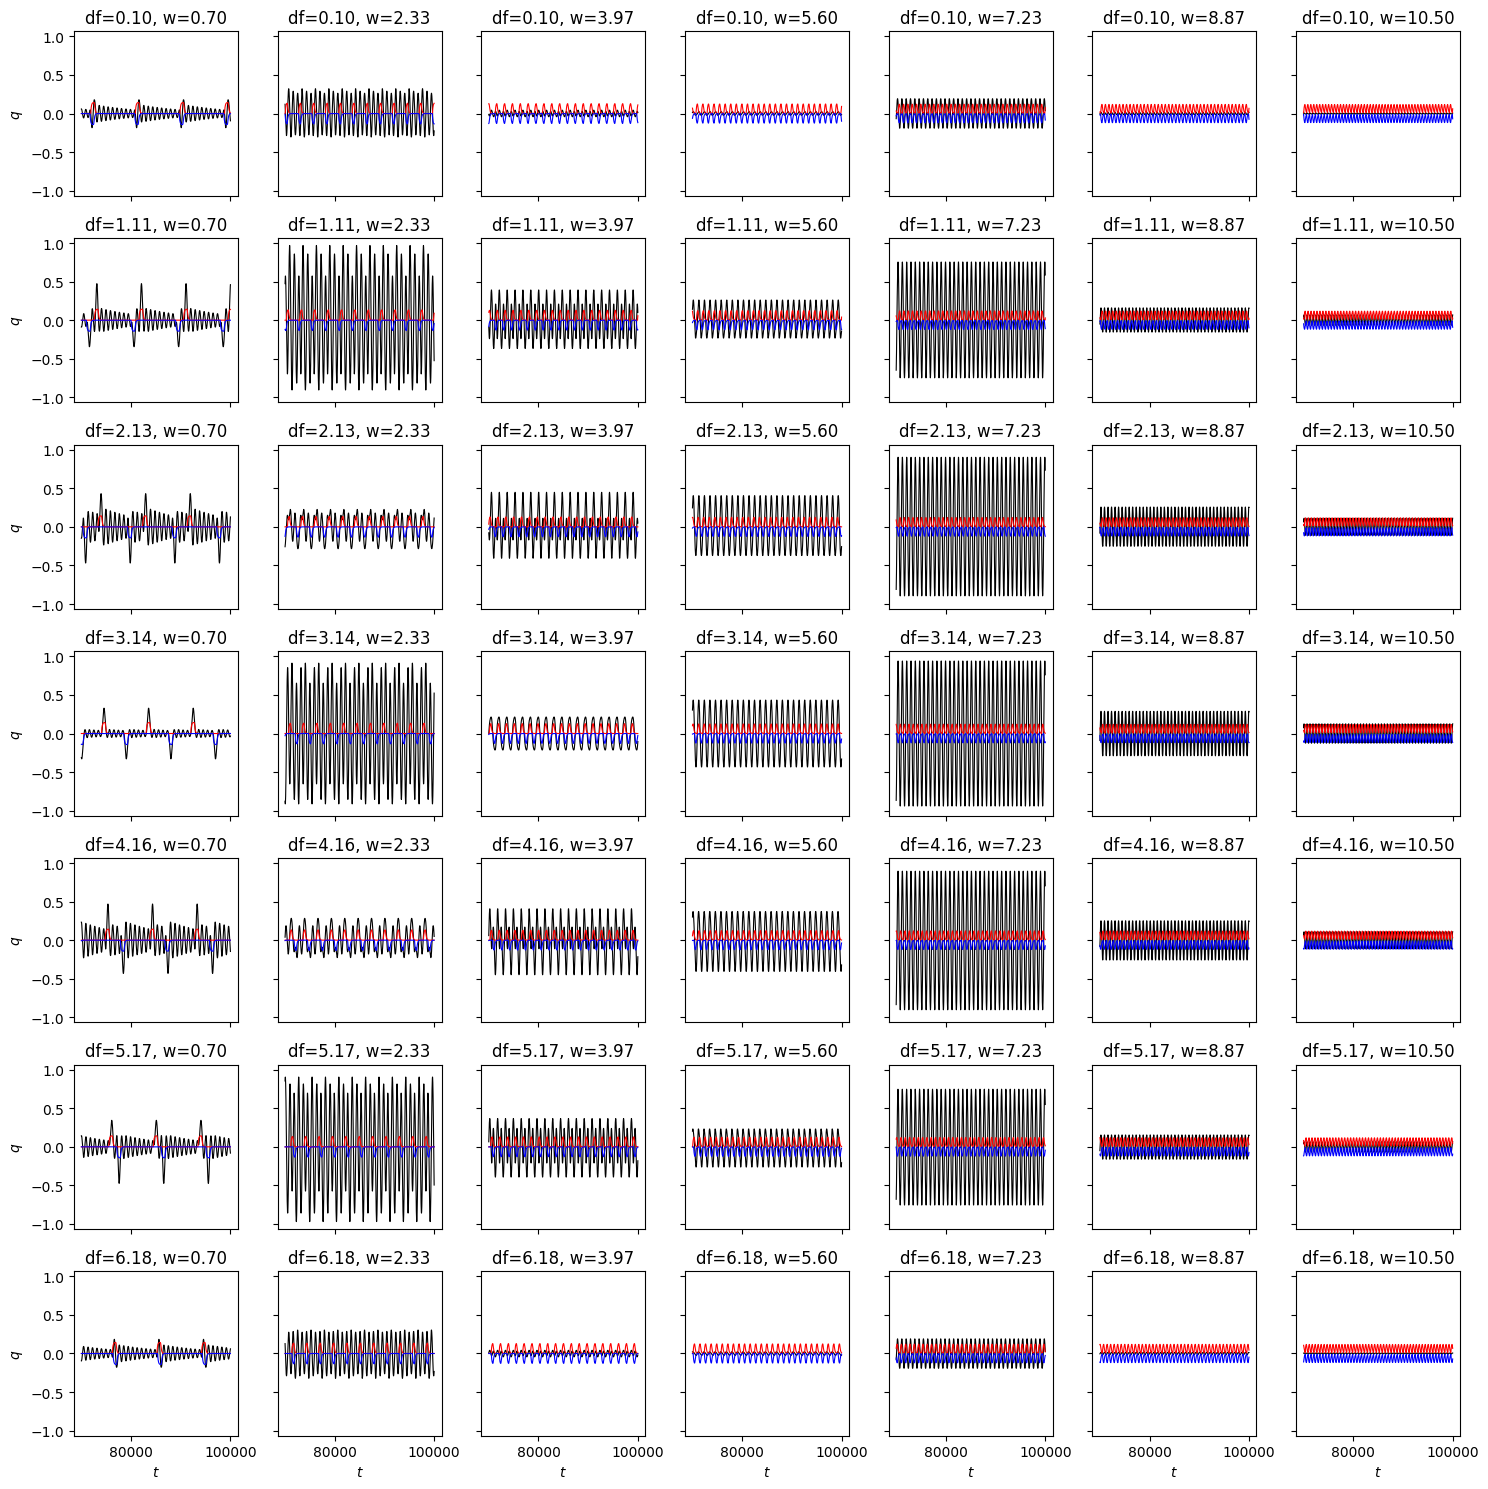

Динамика угла для A=0.2


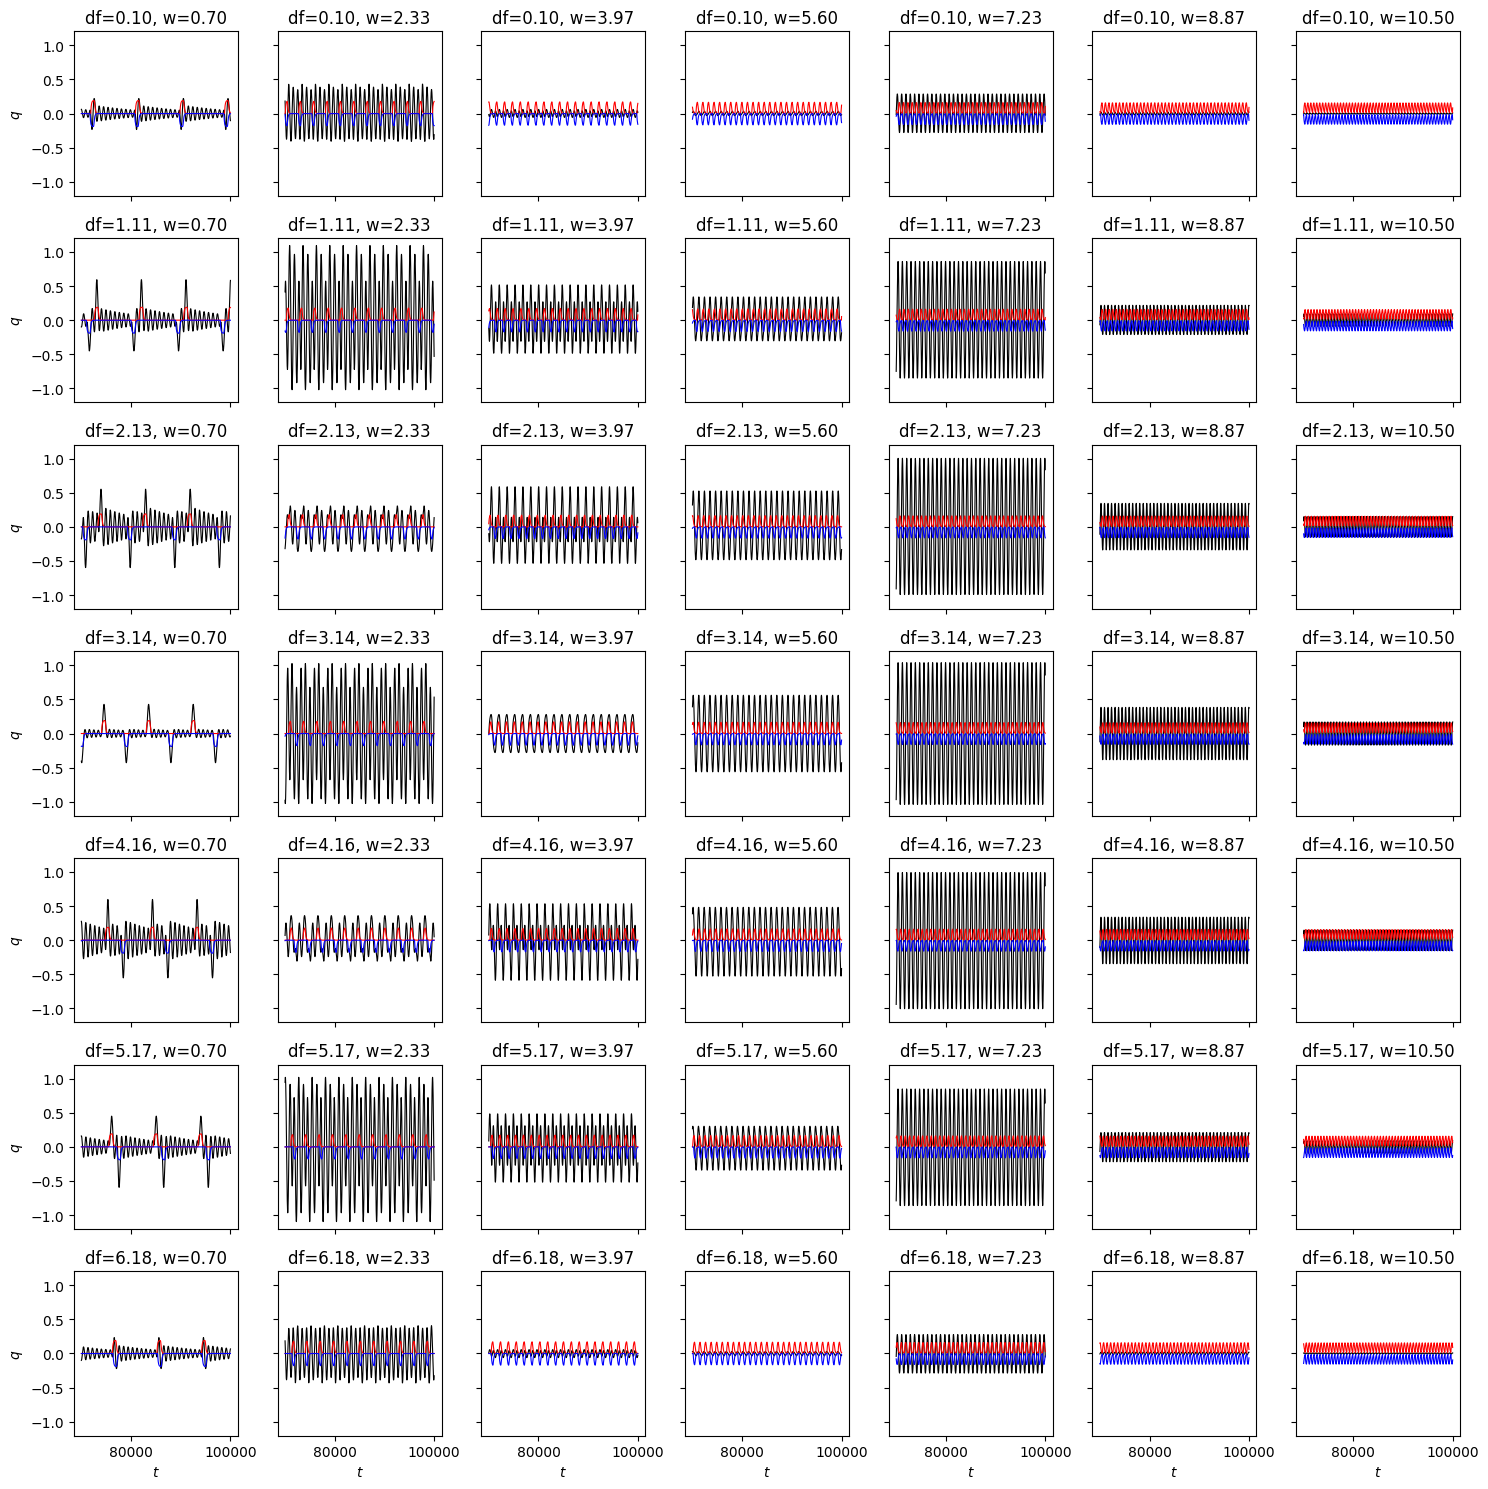

Динамика угла для A=0.25


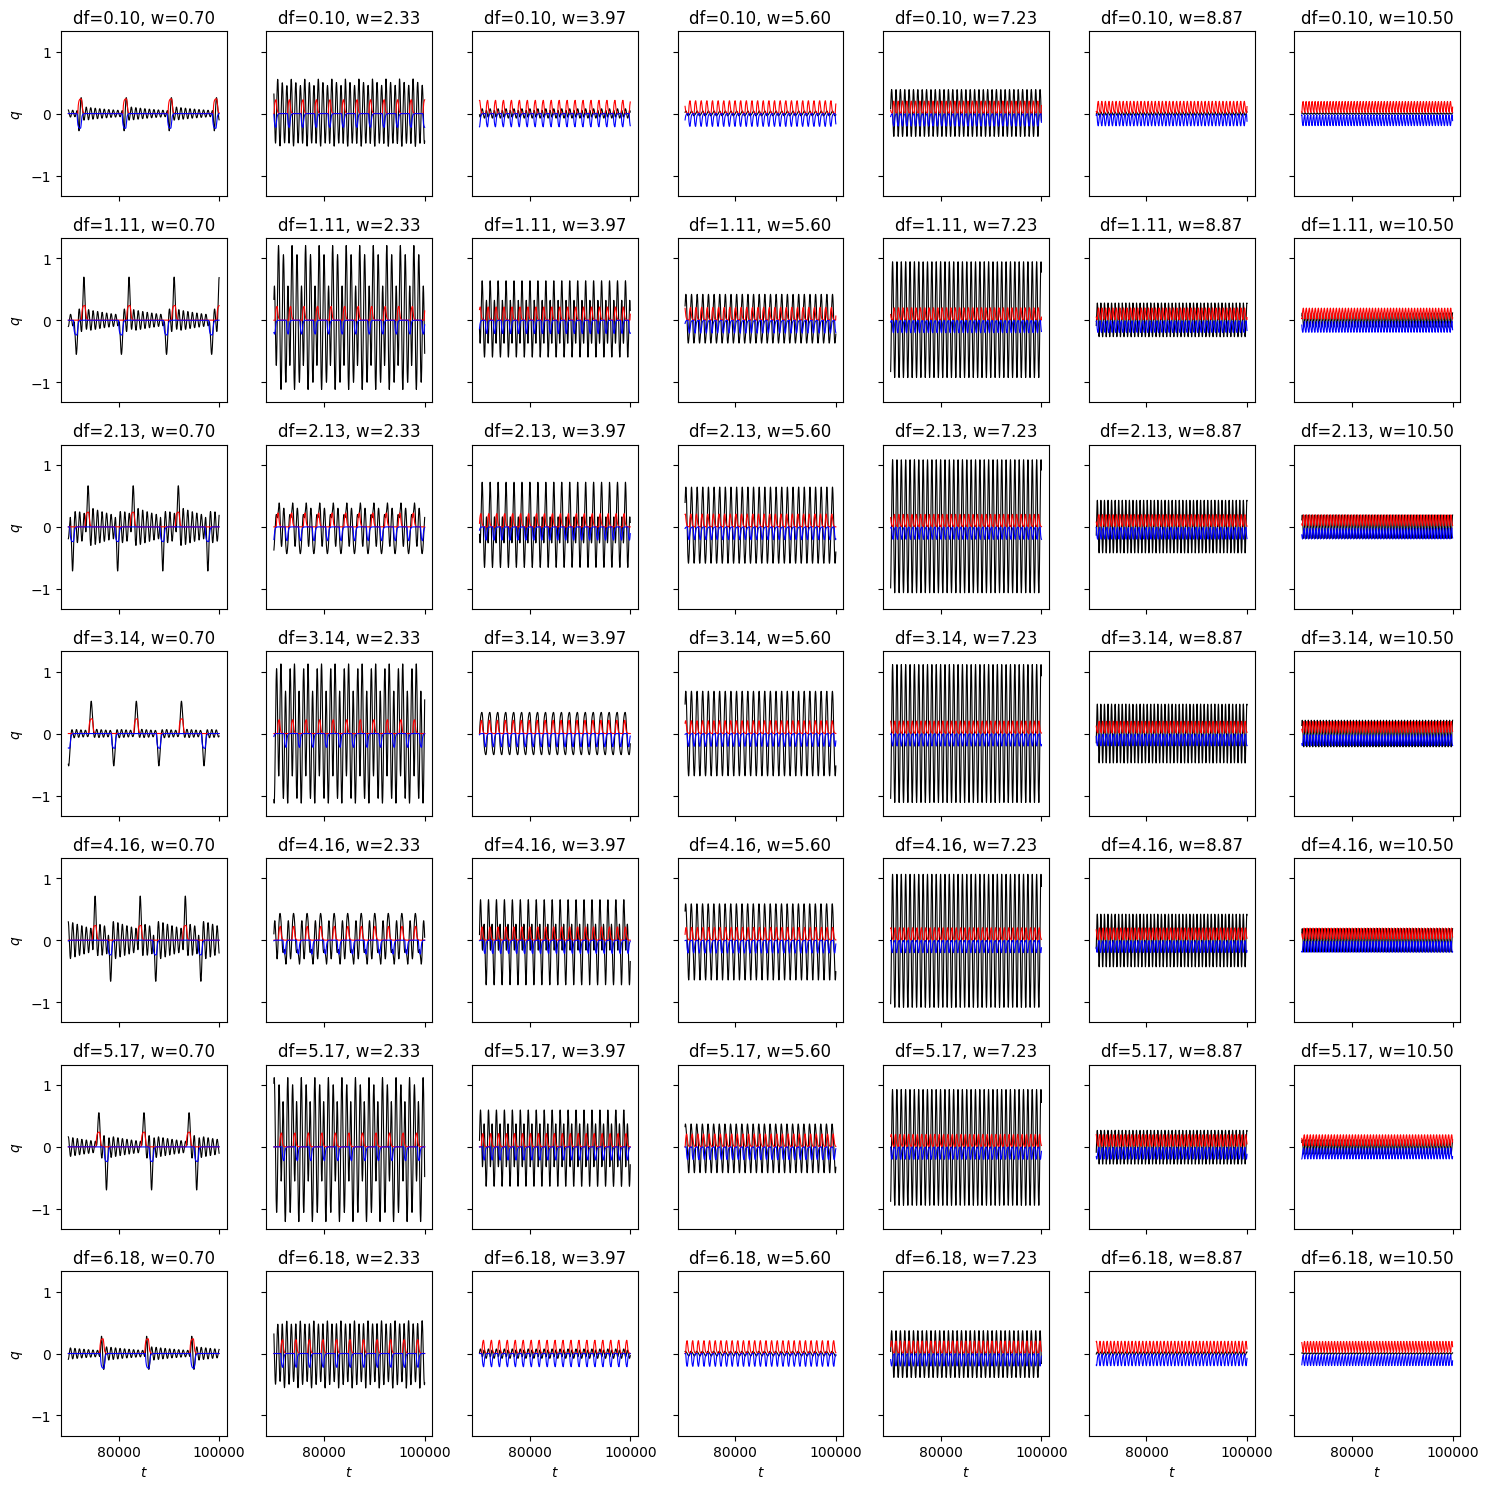

Динамика угла для A=0.3


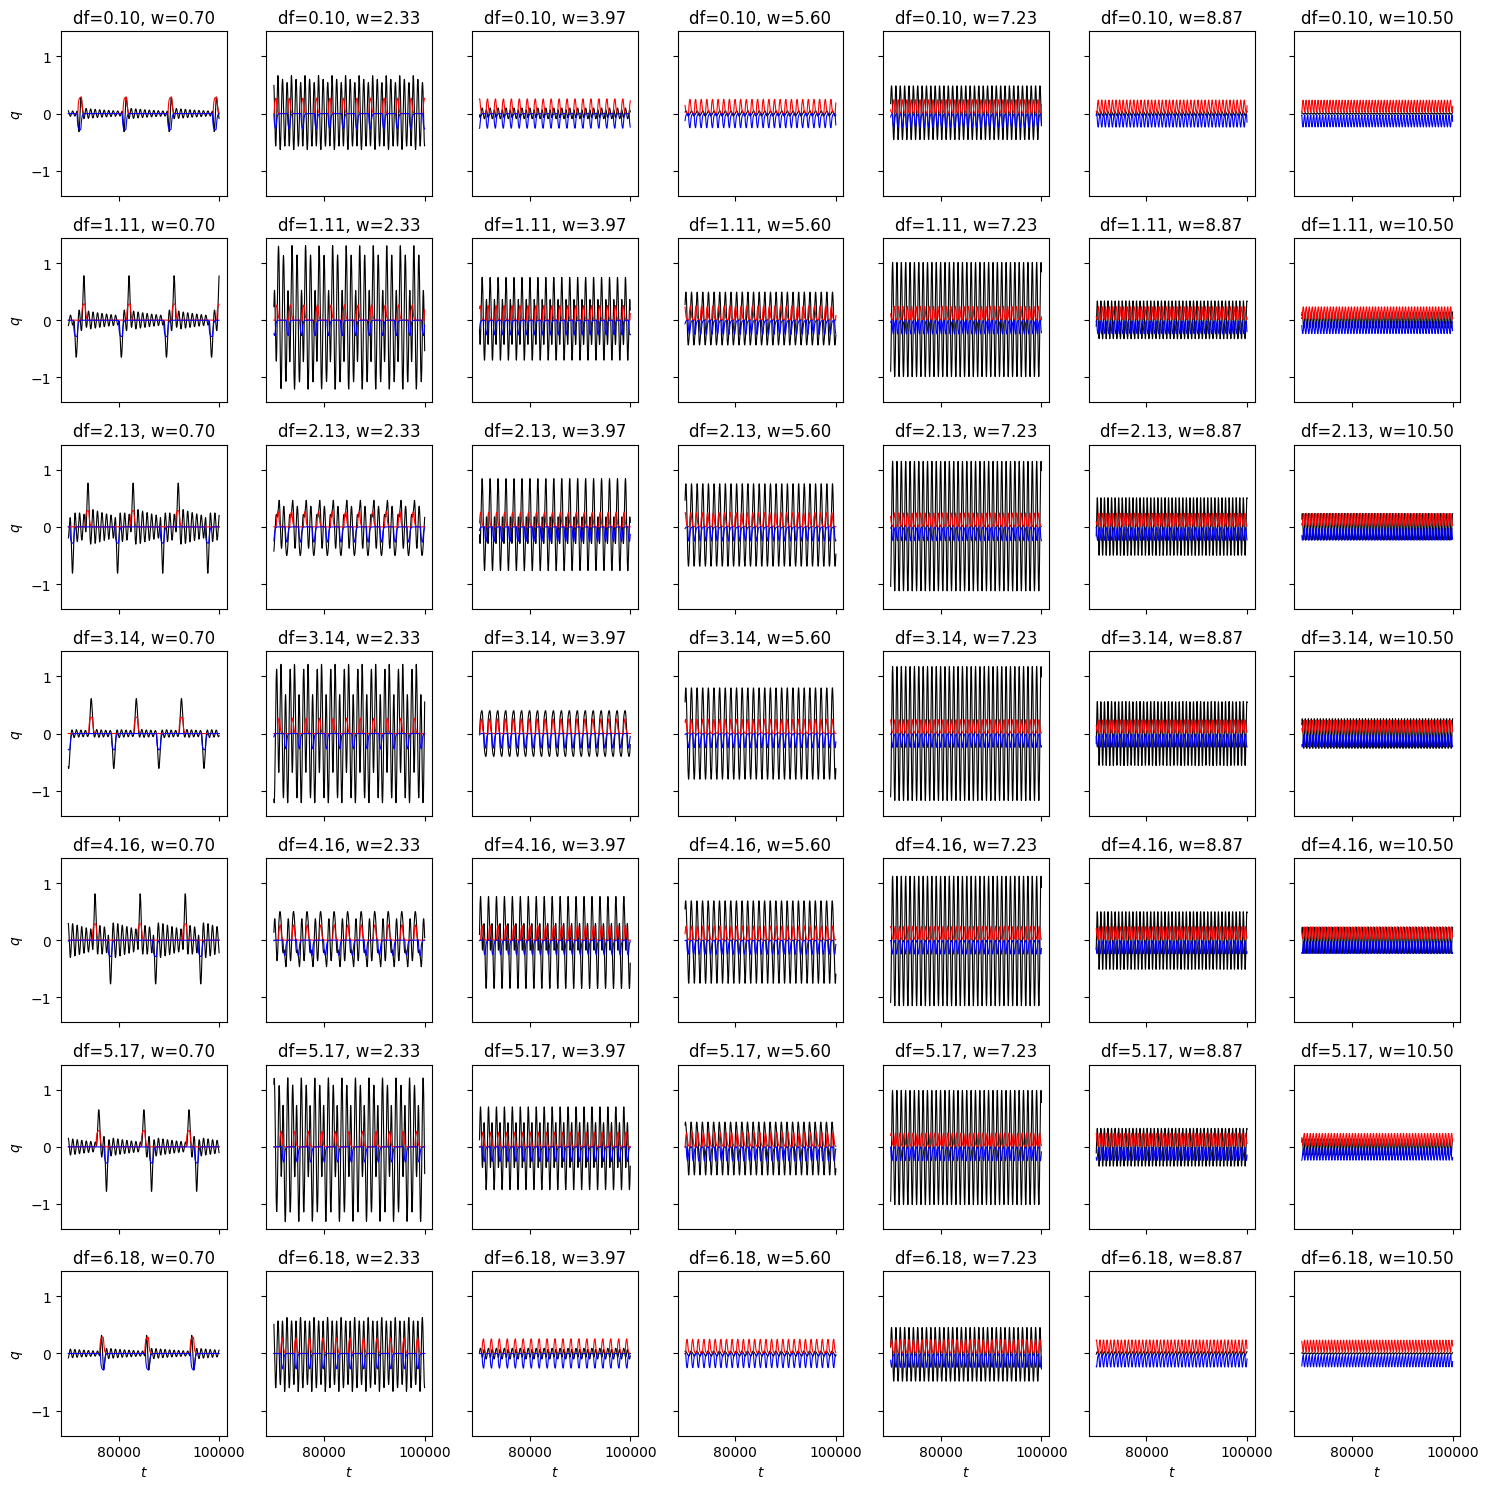

In [9]:
# time sries
def plot_faceted_Q(summary_tab, A, results_dir="results"):
    fig, axes = plt.subplots(len(DF), len(Freqs), figsize=(15, 15), sharex=True, sharey=True)

    fixed_A_tab = summary_tab[summary_tab['A'] == A]
    for i, df in enumerate(DF):
        for j, freq in enumerate(Freqs):
            row=fixed_A_tab[(fixed_A_tab['df'] == df) & (fixed_A_tab['w'] == freq)].iloc[0]
            #print(row['results_file'])
            data = np.load(os.path.join(results_dir, row['results_file']))
            T = data['T']
            mask = T > 70 * 1000
            Q = data['Q'][mask]-np.pi/2
            W = data ['W'][mask]
            T = data['T'][mask]
            F_flex = data['F_flex'][mask]
            F_ext = data['F_ext'][mask]
            axes[i, j].plot(T, Q, '-k', lw=0.8)
            axes[i, j].plot(T, F_flex, '-r', lw=0.8)
            axes[i, j].plot(T, -F_ext, '-b', lw=0.8)
            #axes[i, j].axvline(np.pi/2, c='r')
            #axes[i, j].axvline(-np.pi/2, c='r')
            
            axes[i, j].set_title(f'df={df:.2f}, w={freq:.2f}')
            if i == len(DF) - 1:
                axes[i, j].set_xlabel(r'$t$')
            if j == 0:
                axes[i, j].set_ylabel(r'$q$')
    
    plt.tight_layout()
    print(f'Динамика угла для A={A}')
    plt.show()
for A in Ampls:
    plot_faceted_Q(summary_tab, A, results_dir="results")

## Визуализция фазовых пространств

[0.1  0.15 0.2  0.25 0.3 ]
Фазовые портреты для A=0.1


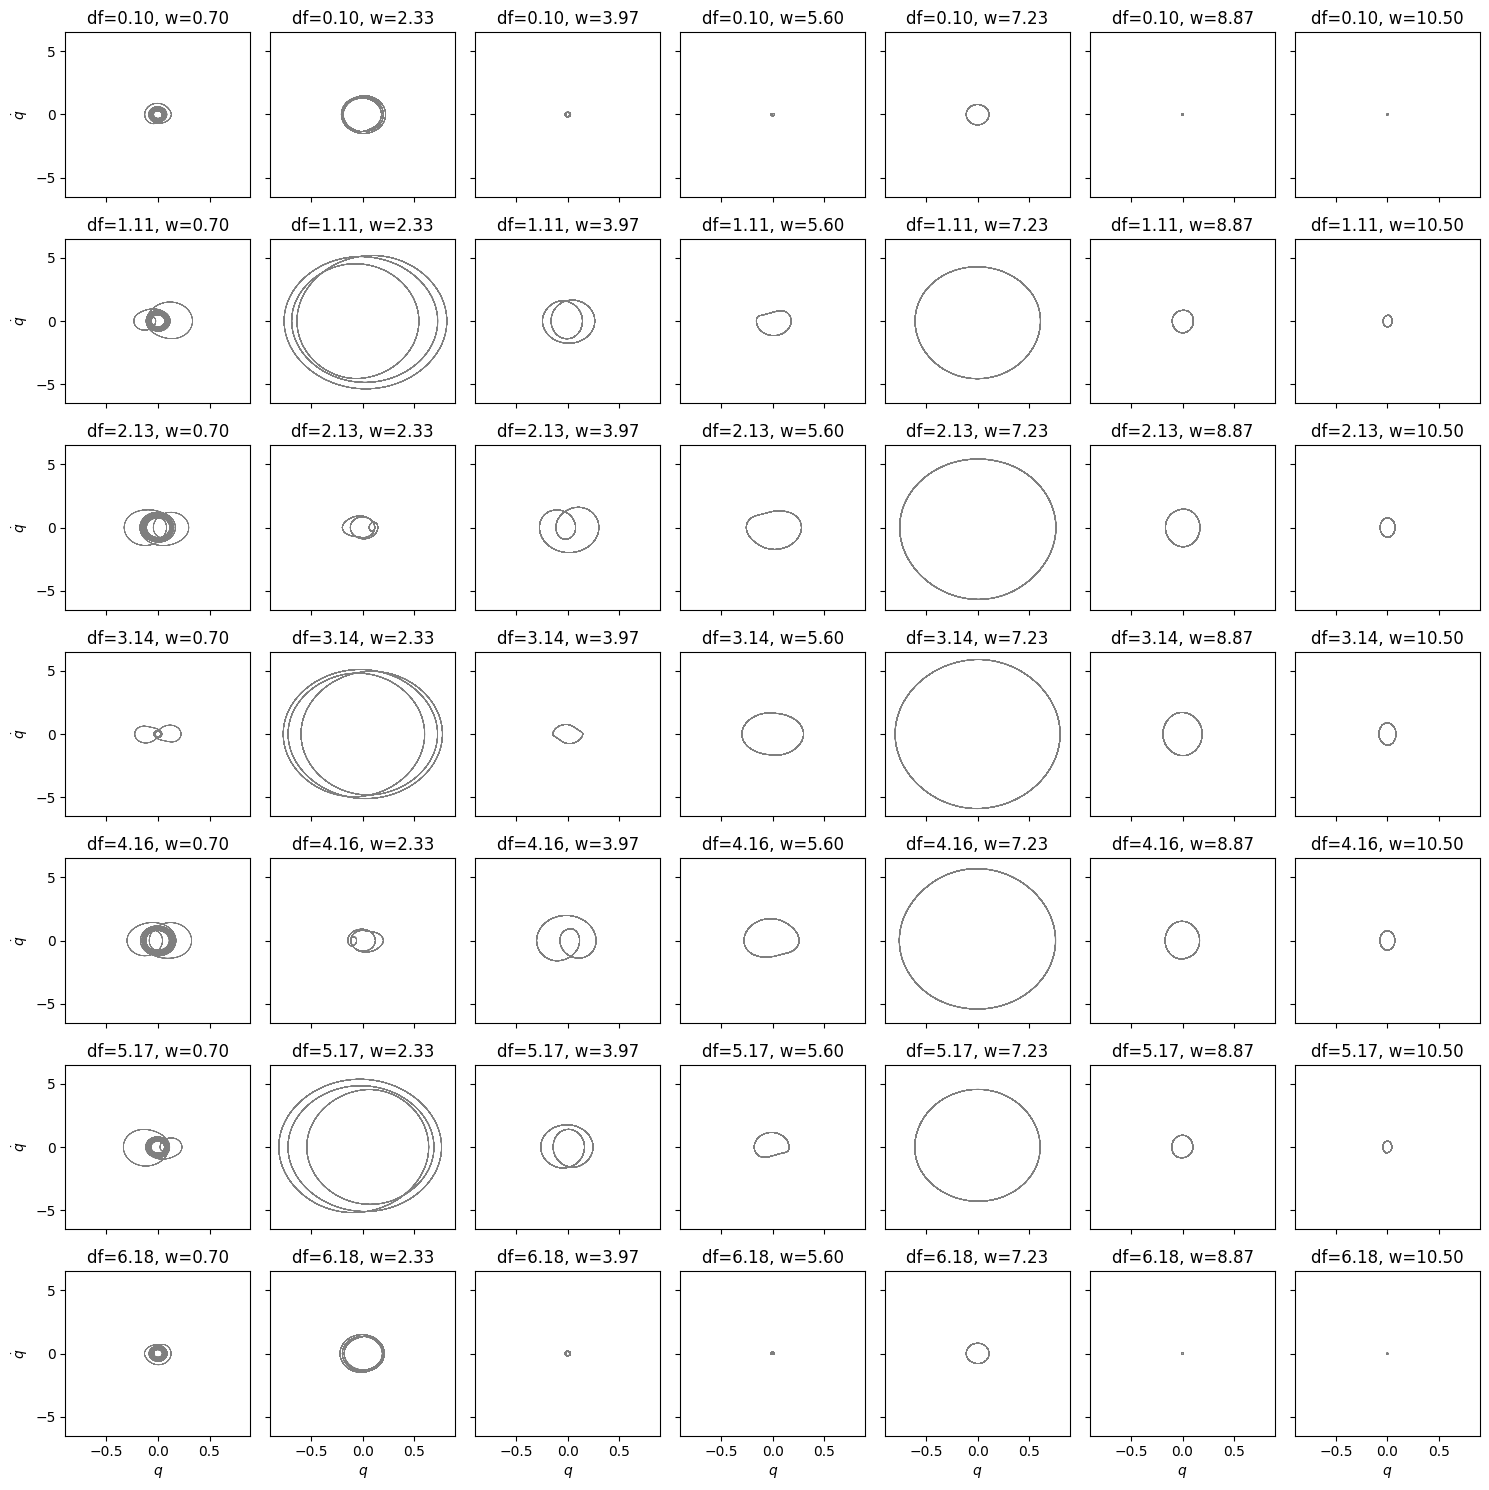

Фазовые портреты для A=0.15


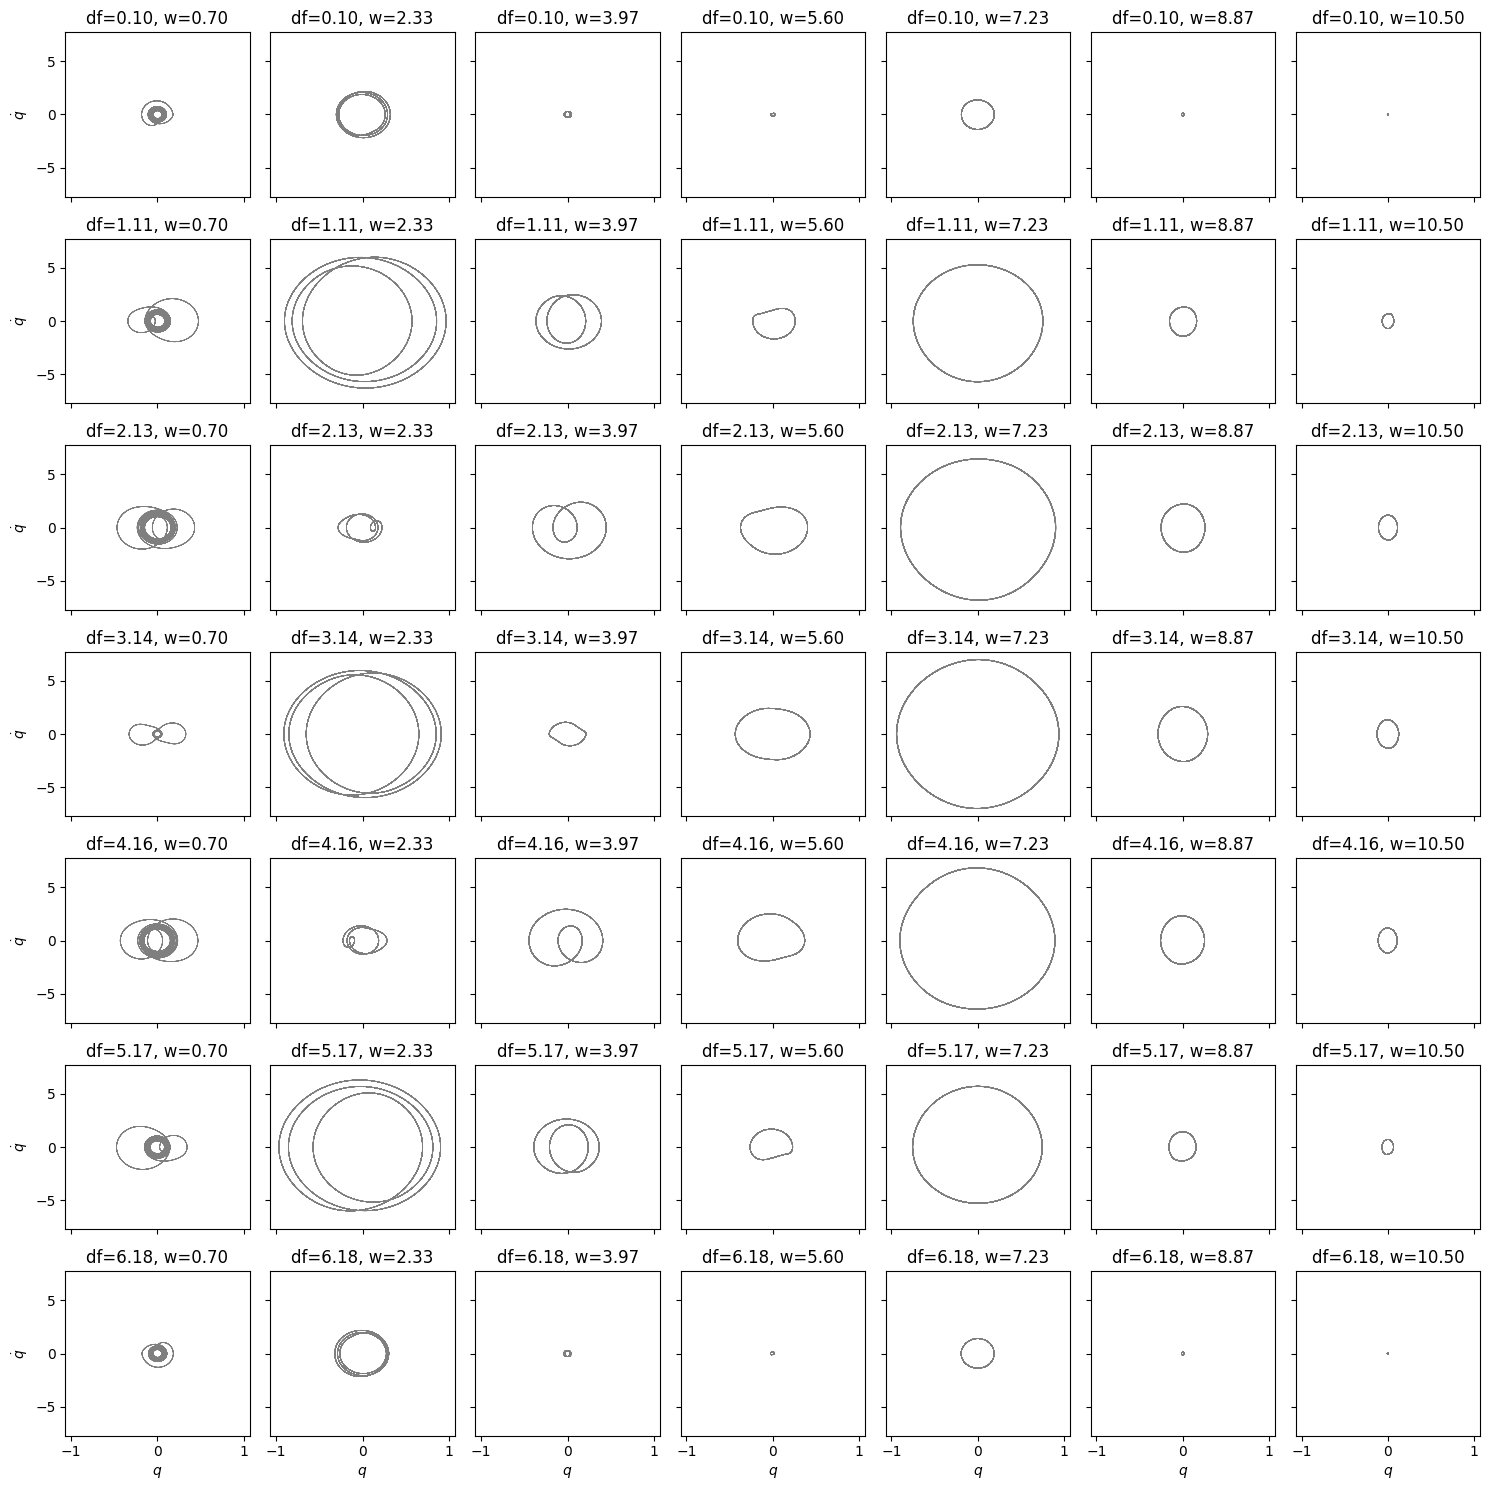

Фазовые портреты для A=0.2


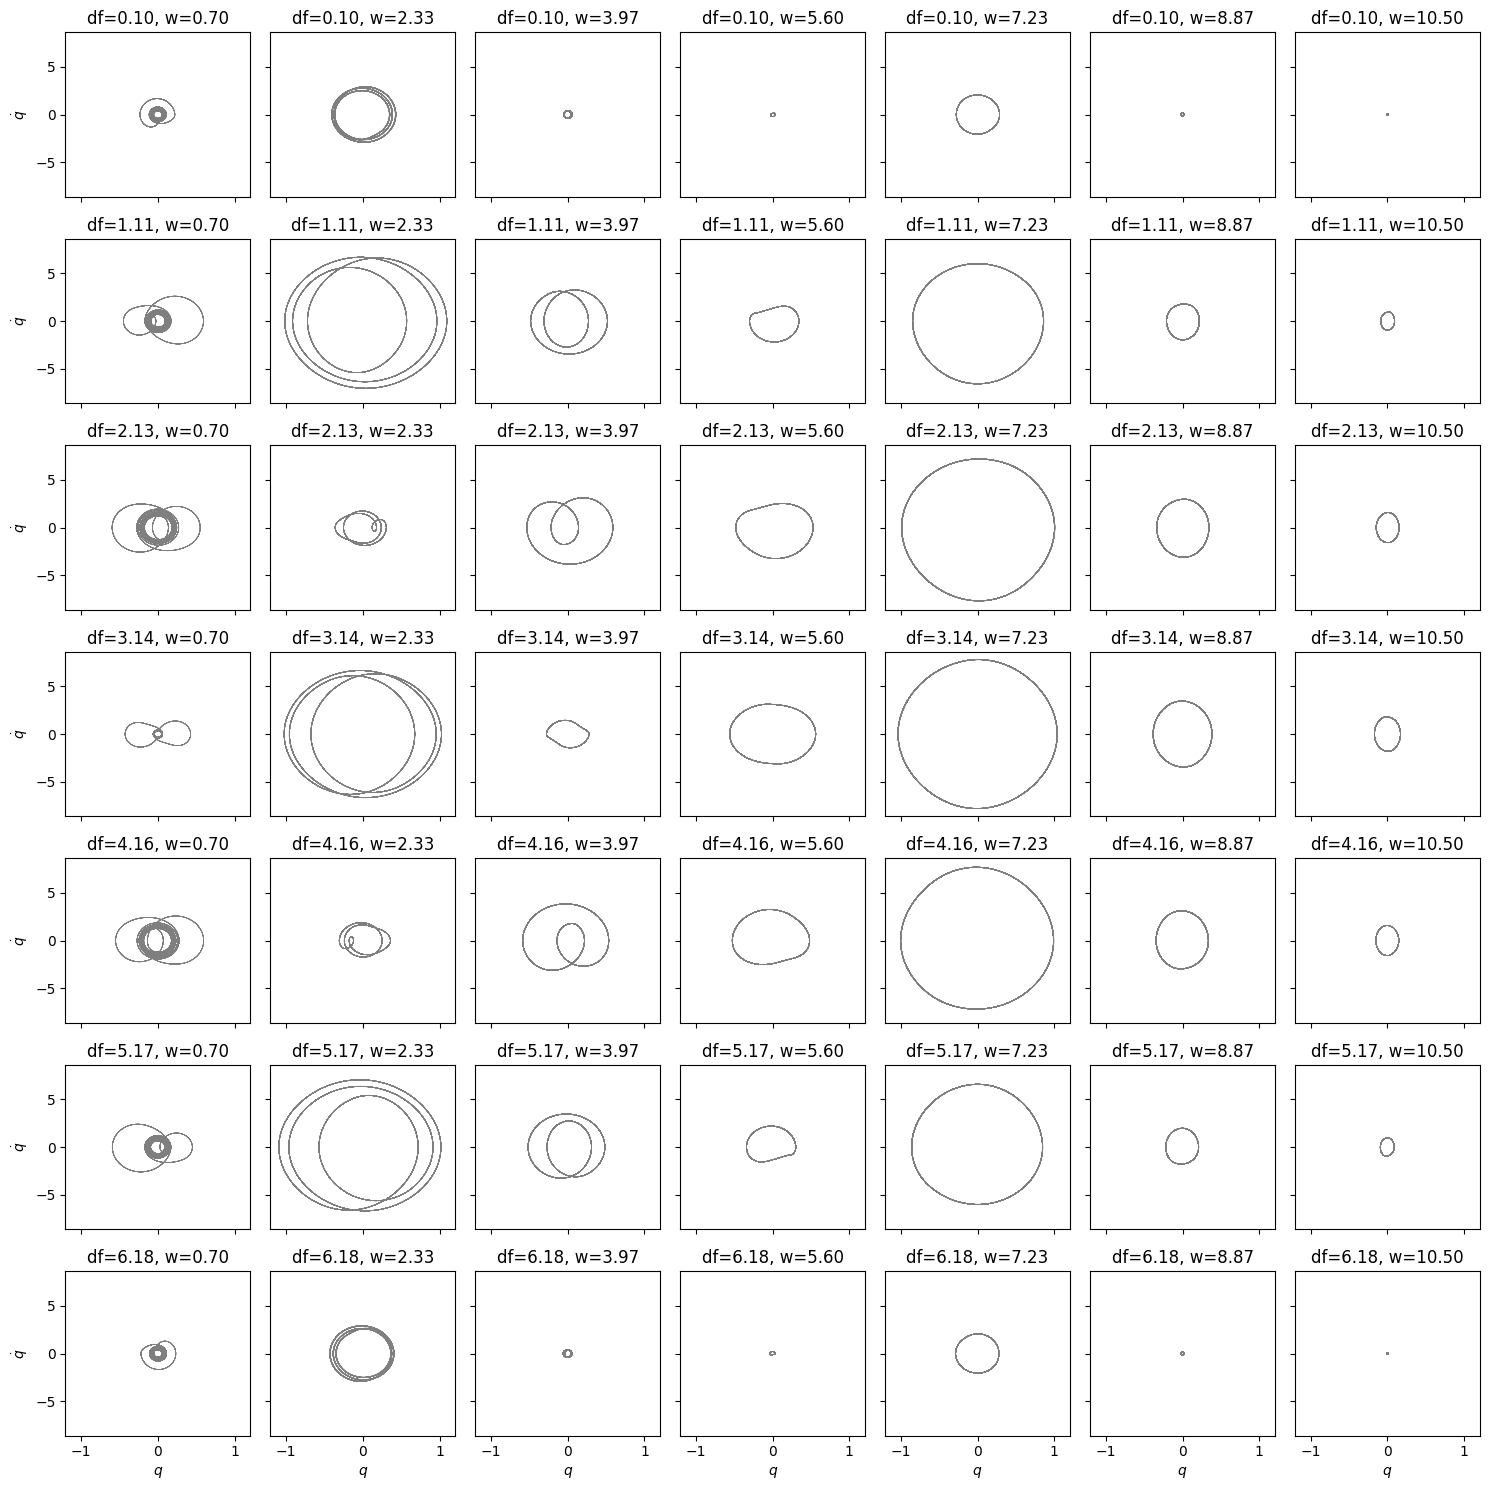

Фазовые портреты для A=0.25


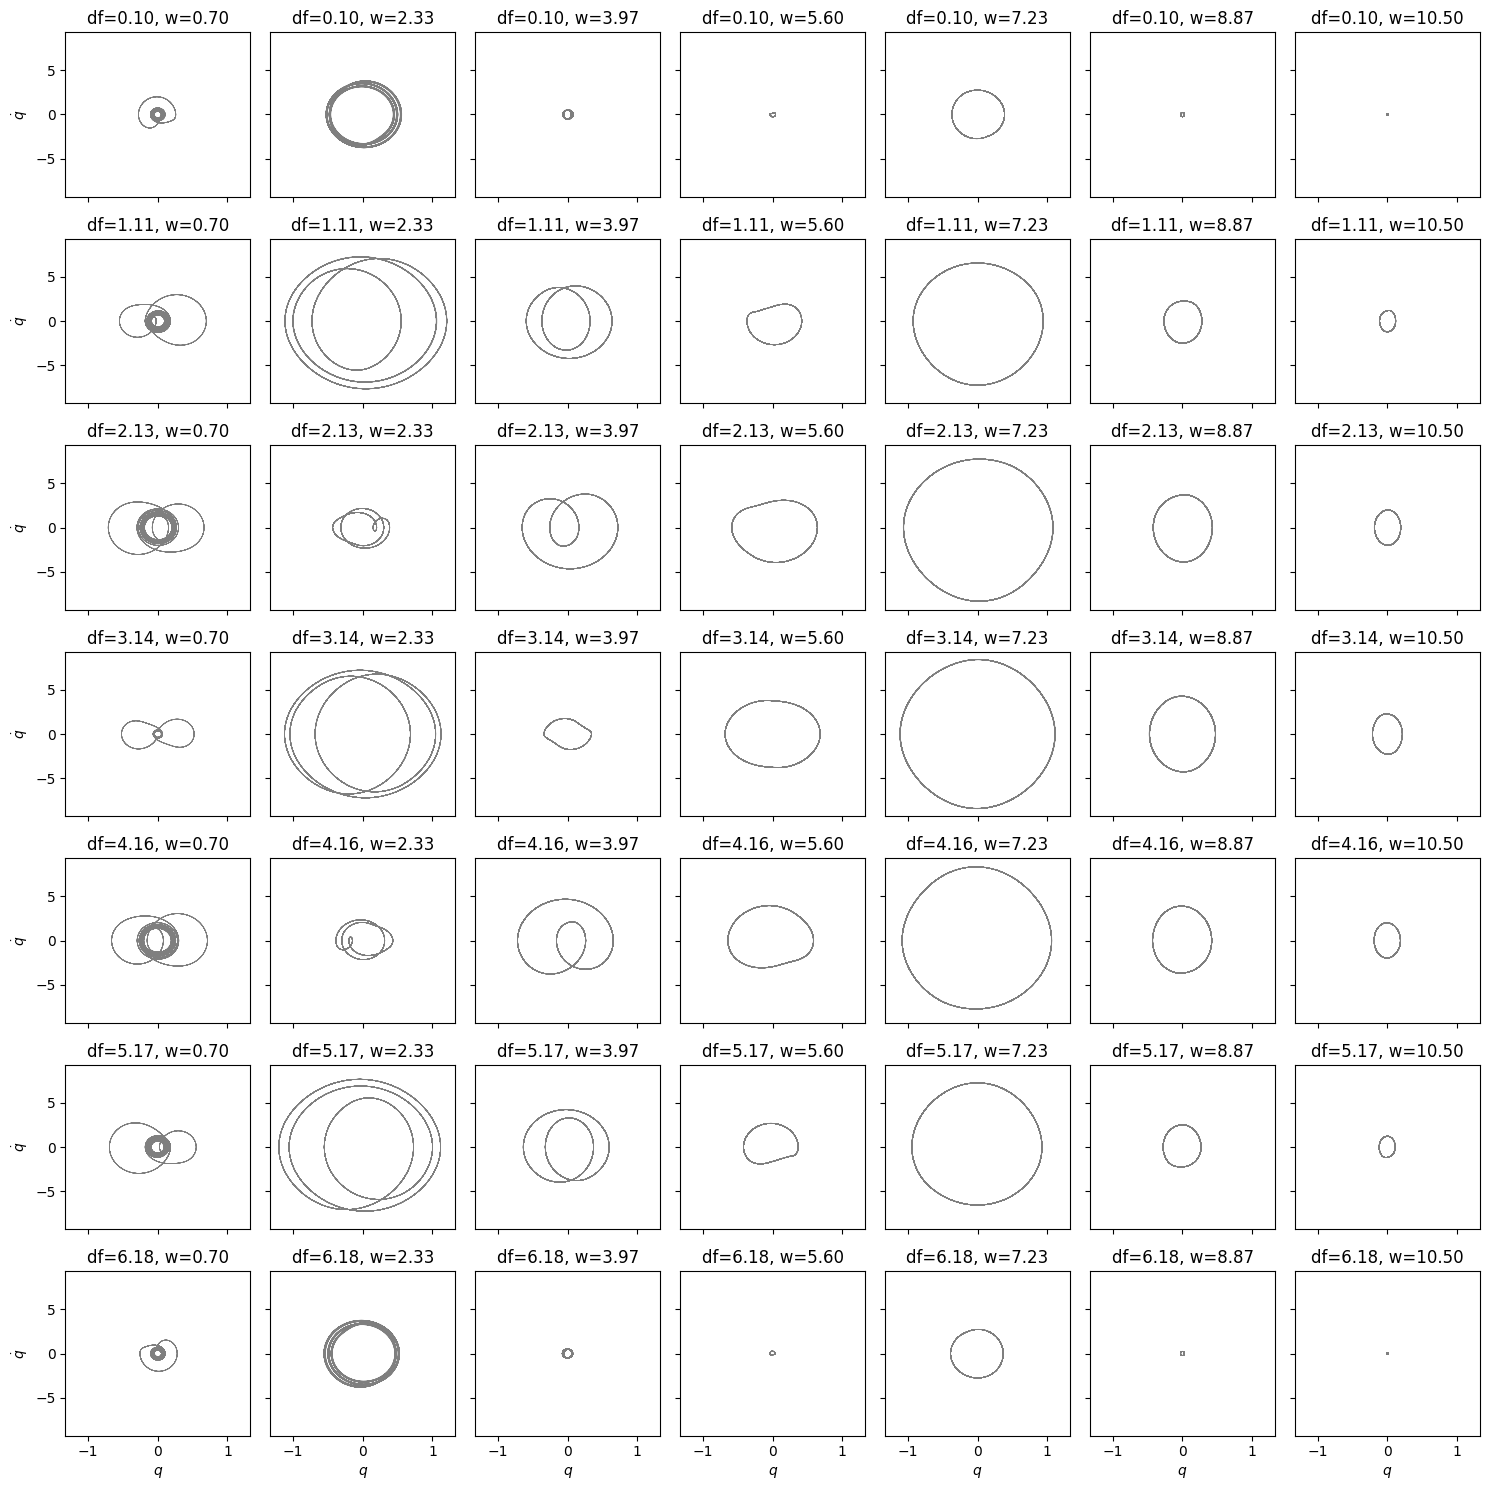

Фазовые портреты для A=0.3


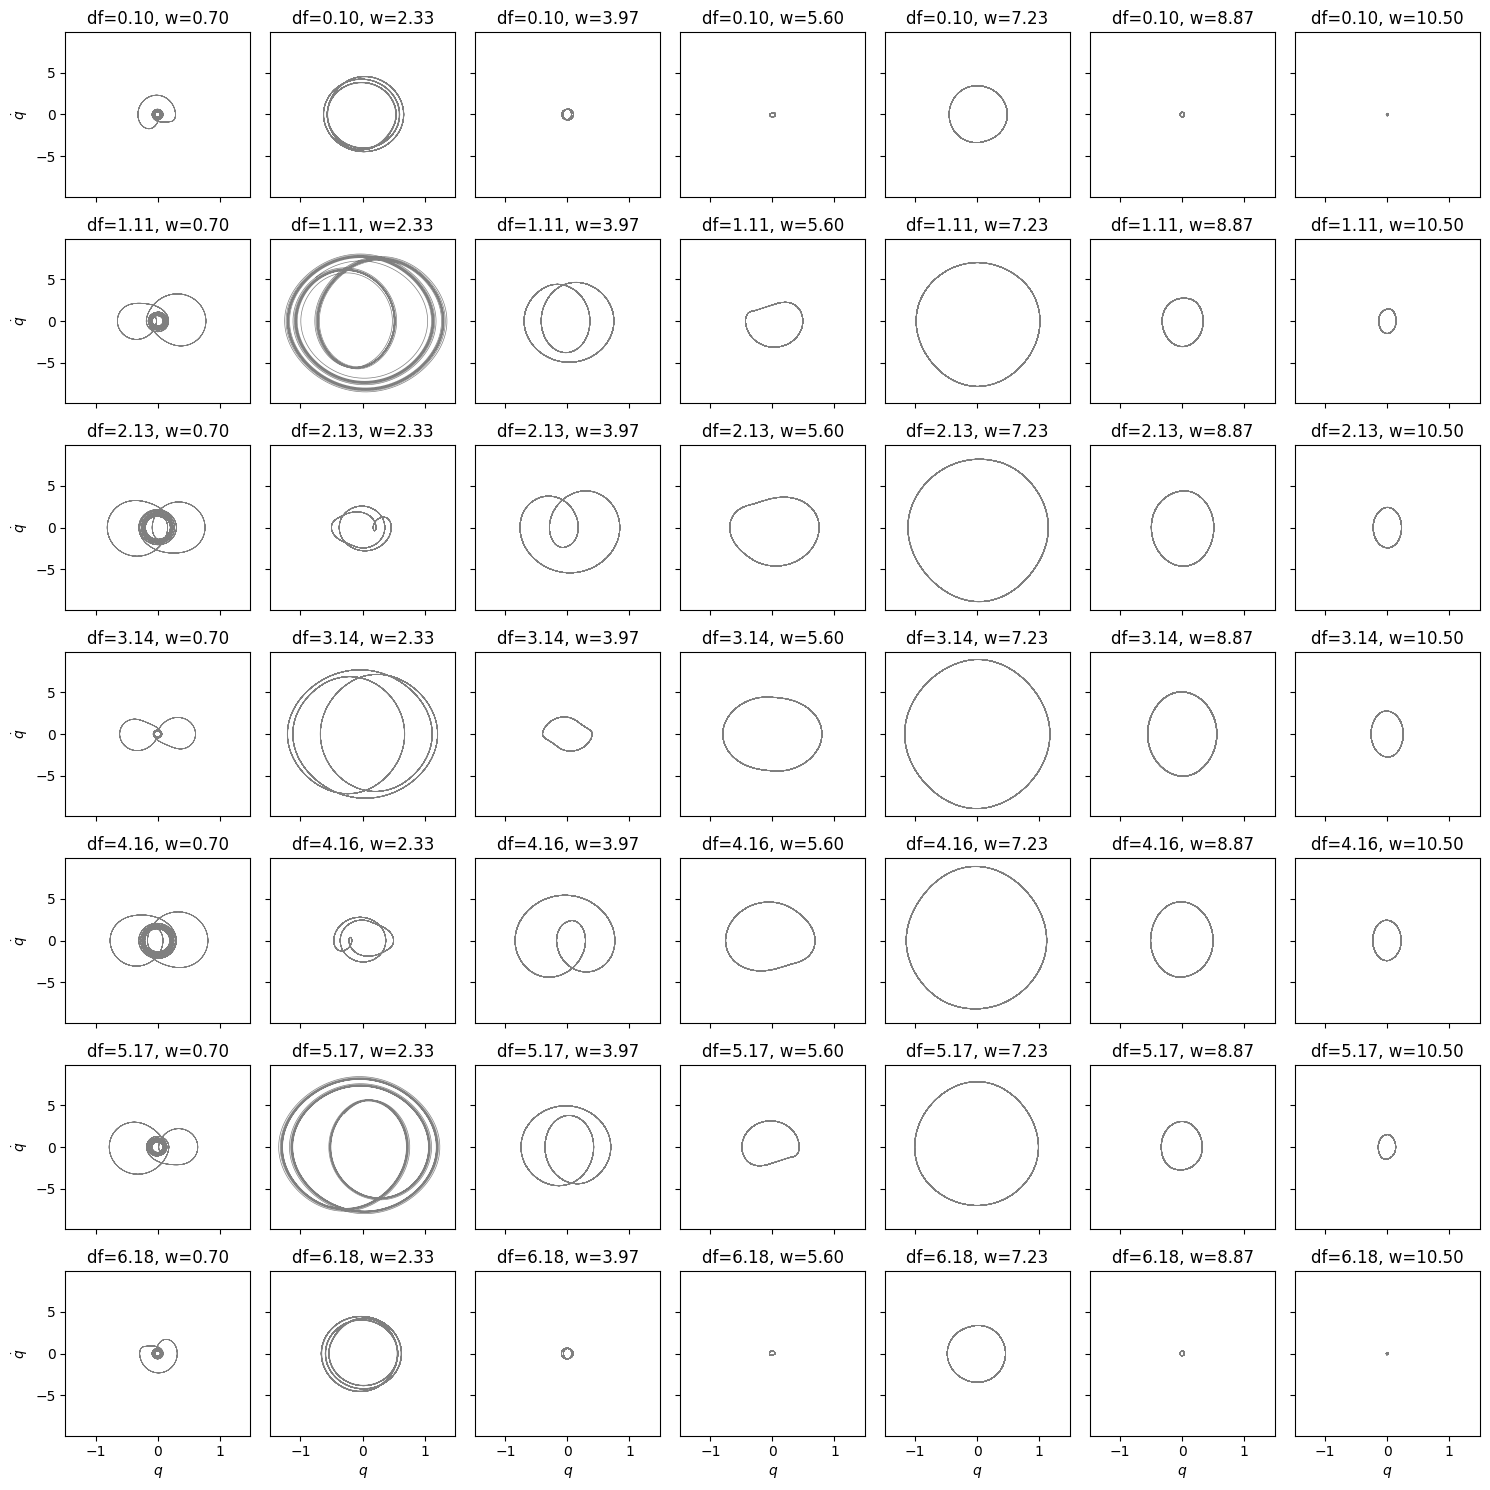

In [10]:
print(Ampls)
def plot_faceted_phase(summary_tab, A, results_dir="results"):
    fig, axes = plt.subplots(len(DF), len(Freqs), figsize=(15, 15), sharex=True, sharey=True)

    fixed_A_tab = summary_tab[summary_tab['A'] == A]
    for i, df in enumerate(DF):
        for j, freq in enumerate(Freqs):
            row=fixed_A_tab[(fixed_A_tab['df'] == df) & (fixed_A_tab['w'] == freq)].iloc[0]
            #print(row['results_file'])
            data = np.load(os.path.join(results_dir, row['results_file']))
            T = data['T']
            mask = T > 50 * 1000
            Q = data['Q'][mask]-np.pi/2
            W = data ['W'][mask]
            T = data['T']
            
            axes[i, j].plot(Q, W, 'k-', lw=0.5, alpha=0.5)
            #axes[i, j].axvline(np.pi/2, c='r')
            #axes[i, j].axvline(-np.pi/2, c='r')
            
            axes[i, j].set_title(f'df={df:.2f}, w={freq:.2f}')
            if i == len(DF) - 1:
                axes[i, j].set_xlabel(r'$q$')
            if j == 0:
                axes[i, j].set_ylabel(r'$\dot{q}$')
    
    plt.tight_layout()
    print(f'Фазовые портреты для A={A}')
    plt.show()
for A in Ampls:
    plot_faceted_phase(summary_tab, A, results_dir="results")

## Визуализация сечений Пуанкаре через периоды внешней силы
Рассмотрим пики напряжения сгибателя и в эти времена будем откладывать точки на фазовом пространстве

[0.1  0.15 0.2  0.25 0.3 ]
Фазовые портреты для A=0.1


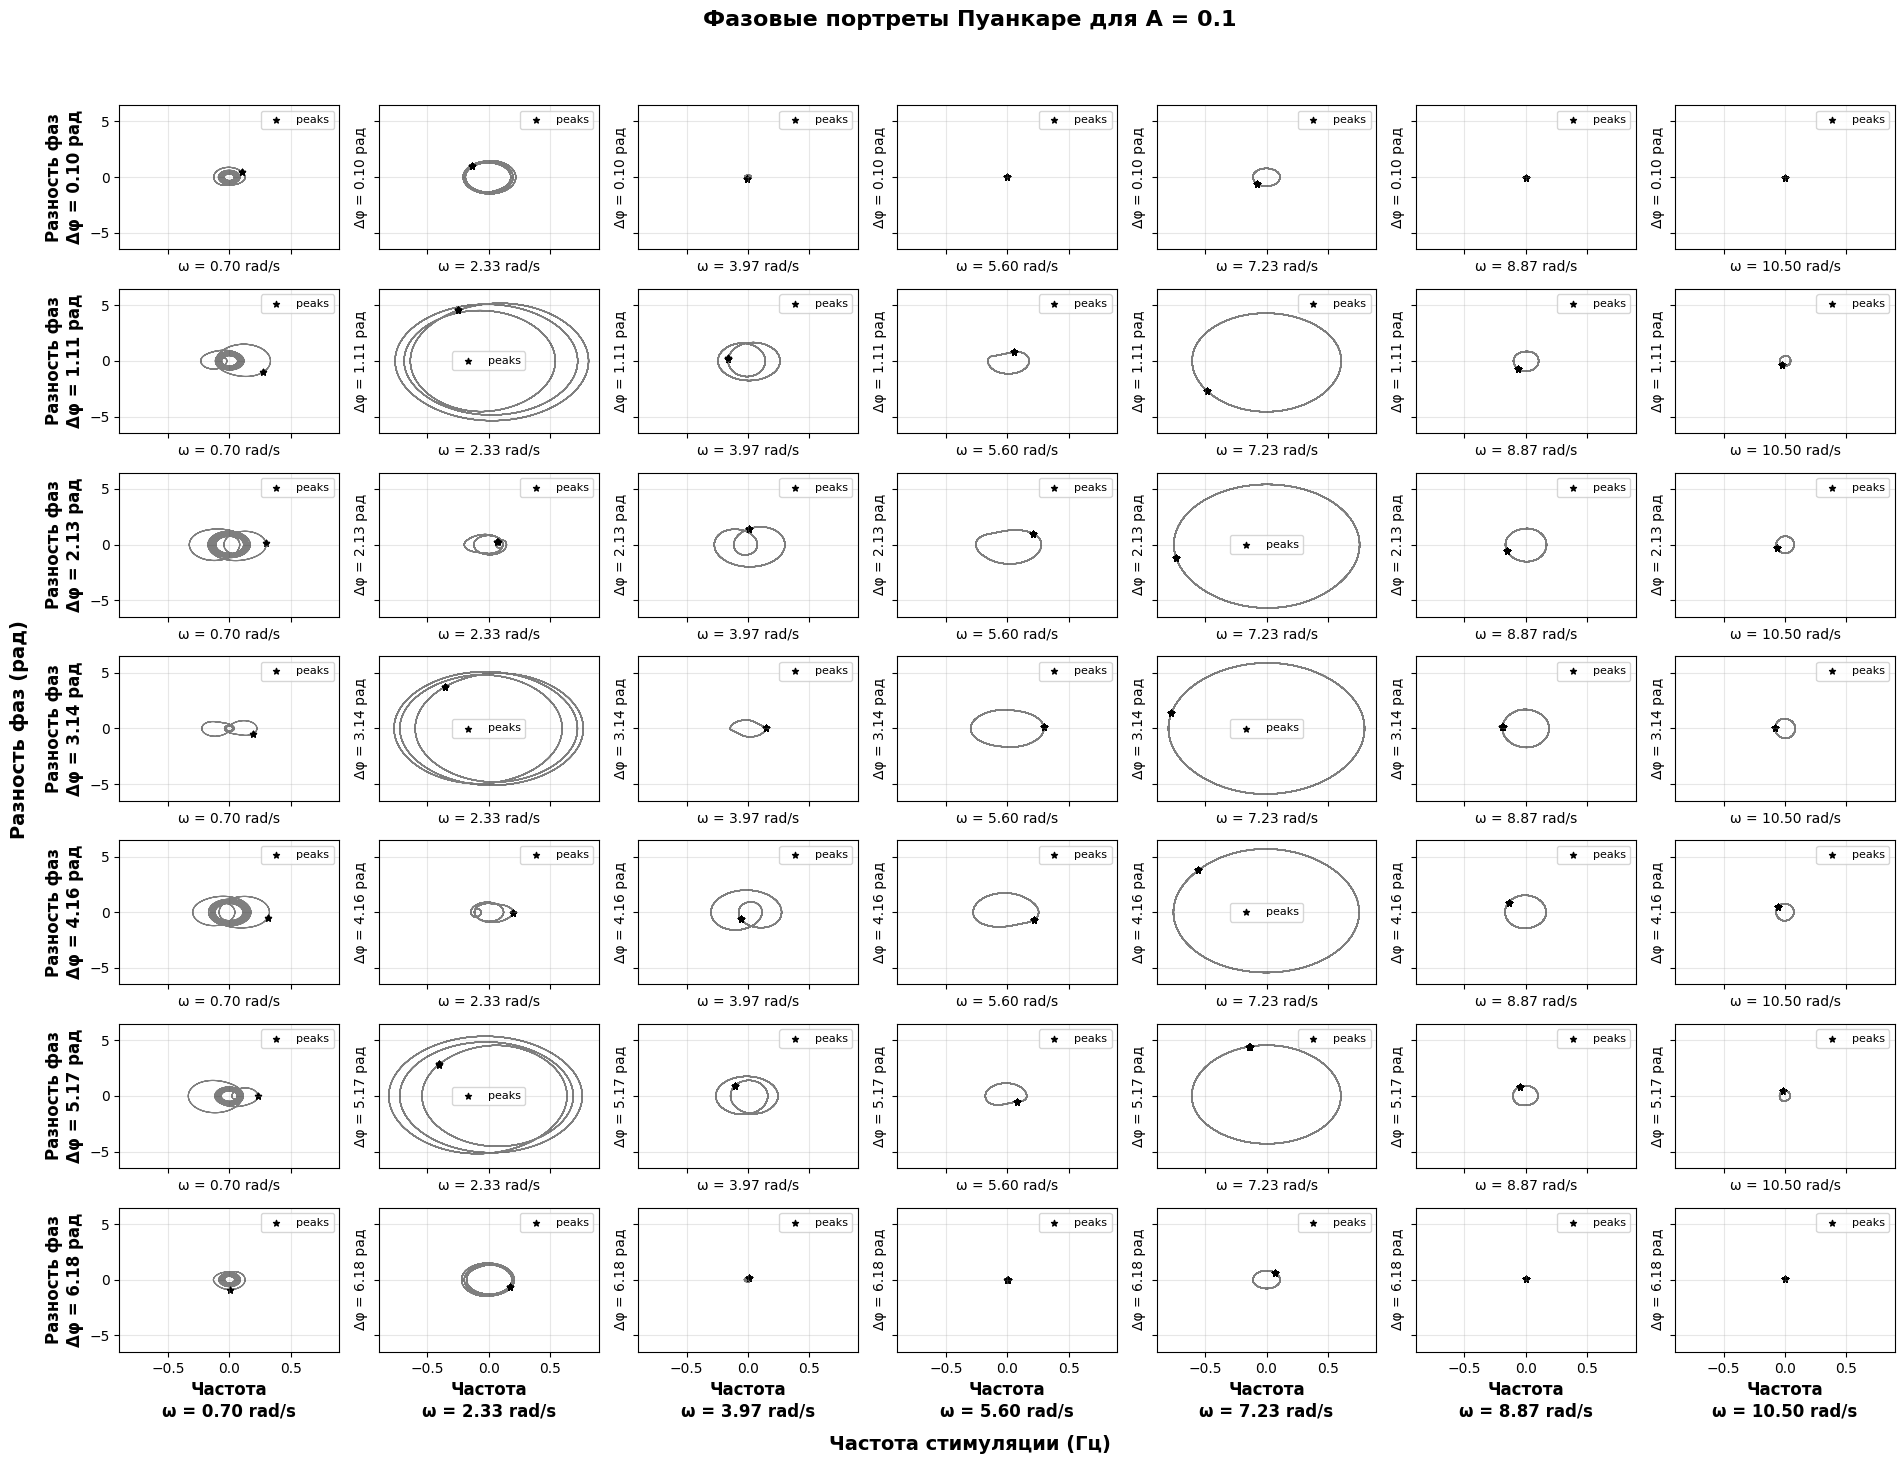

Фазовые портреты для A=0.15


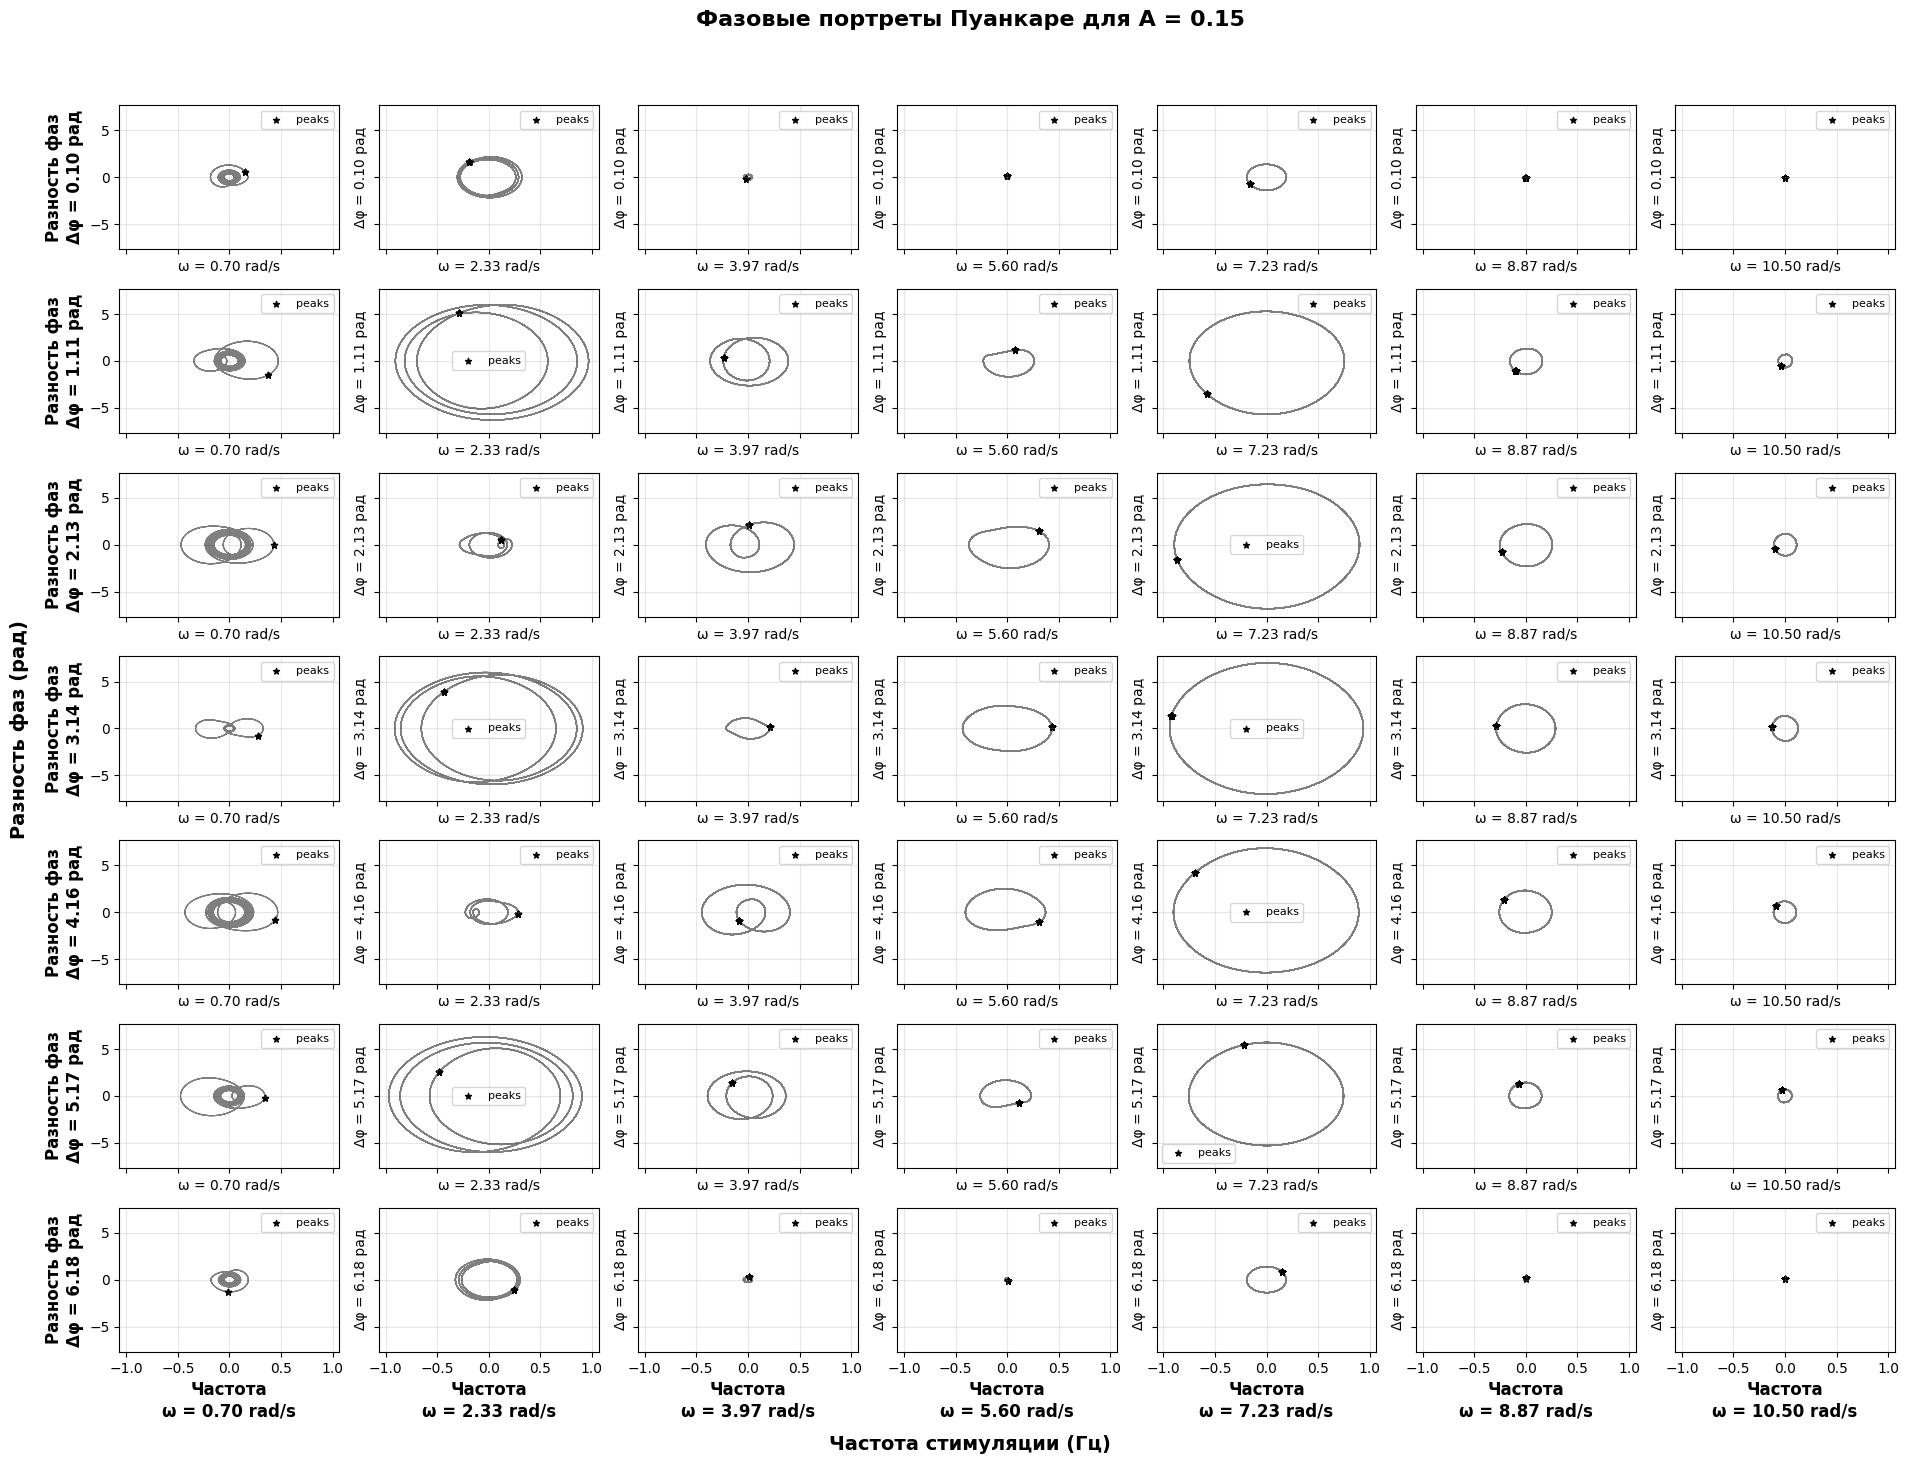

Фазовые портреты для A=0.2


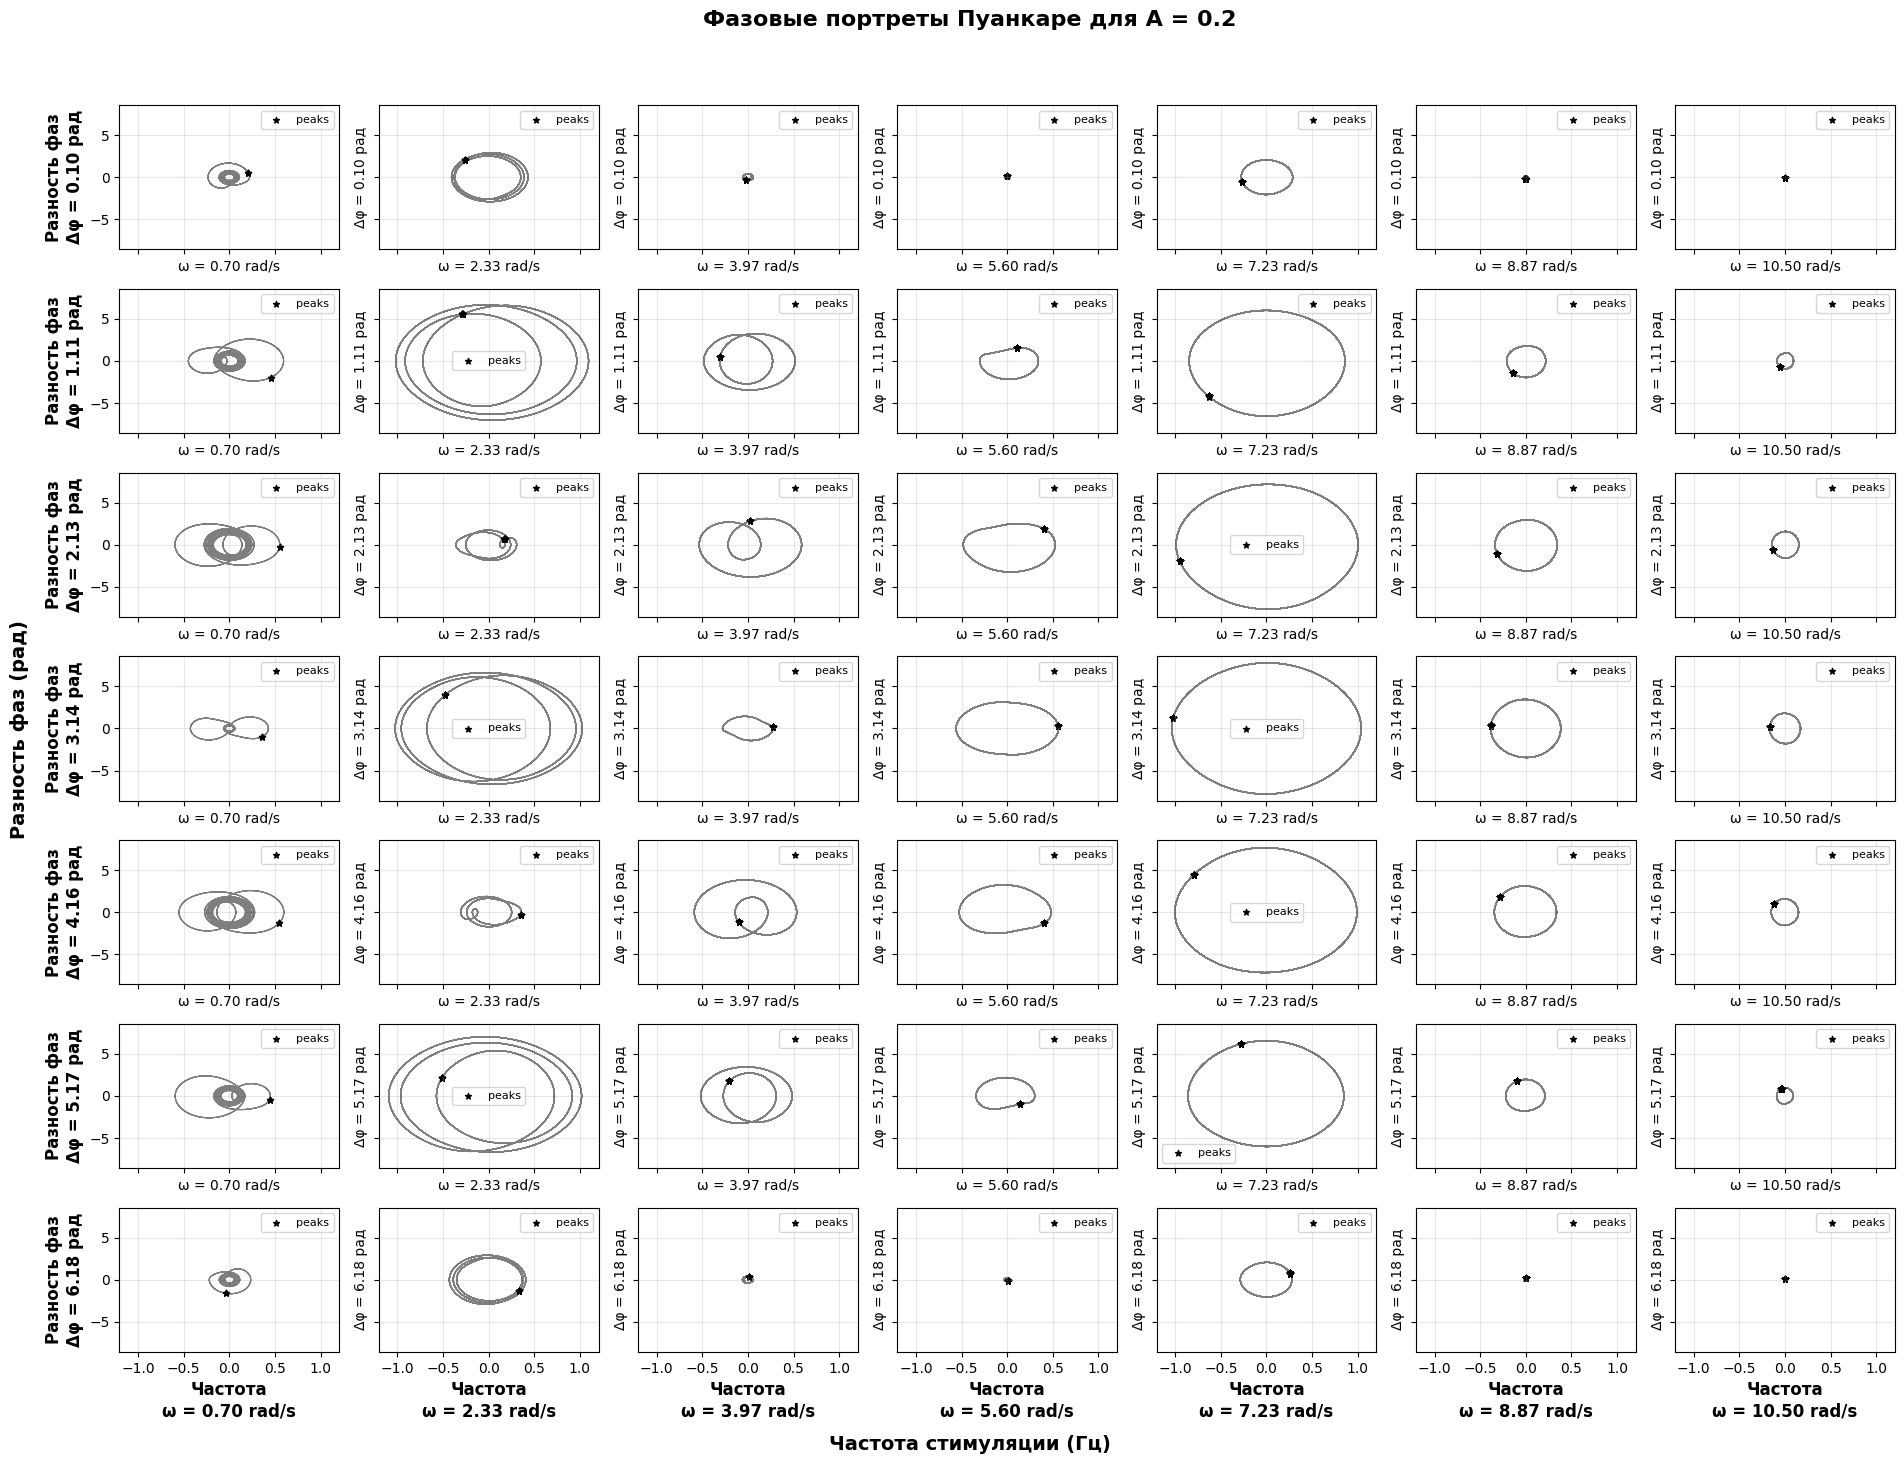

Фазовые портреты для A=0.25


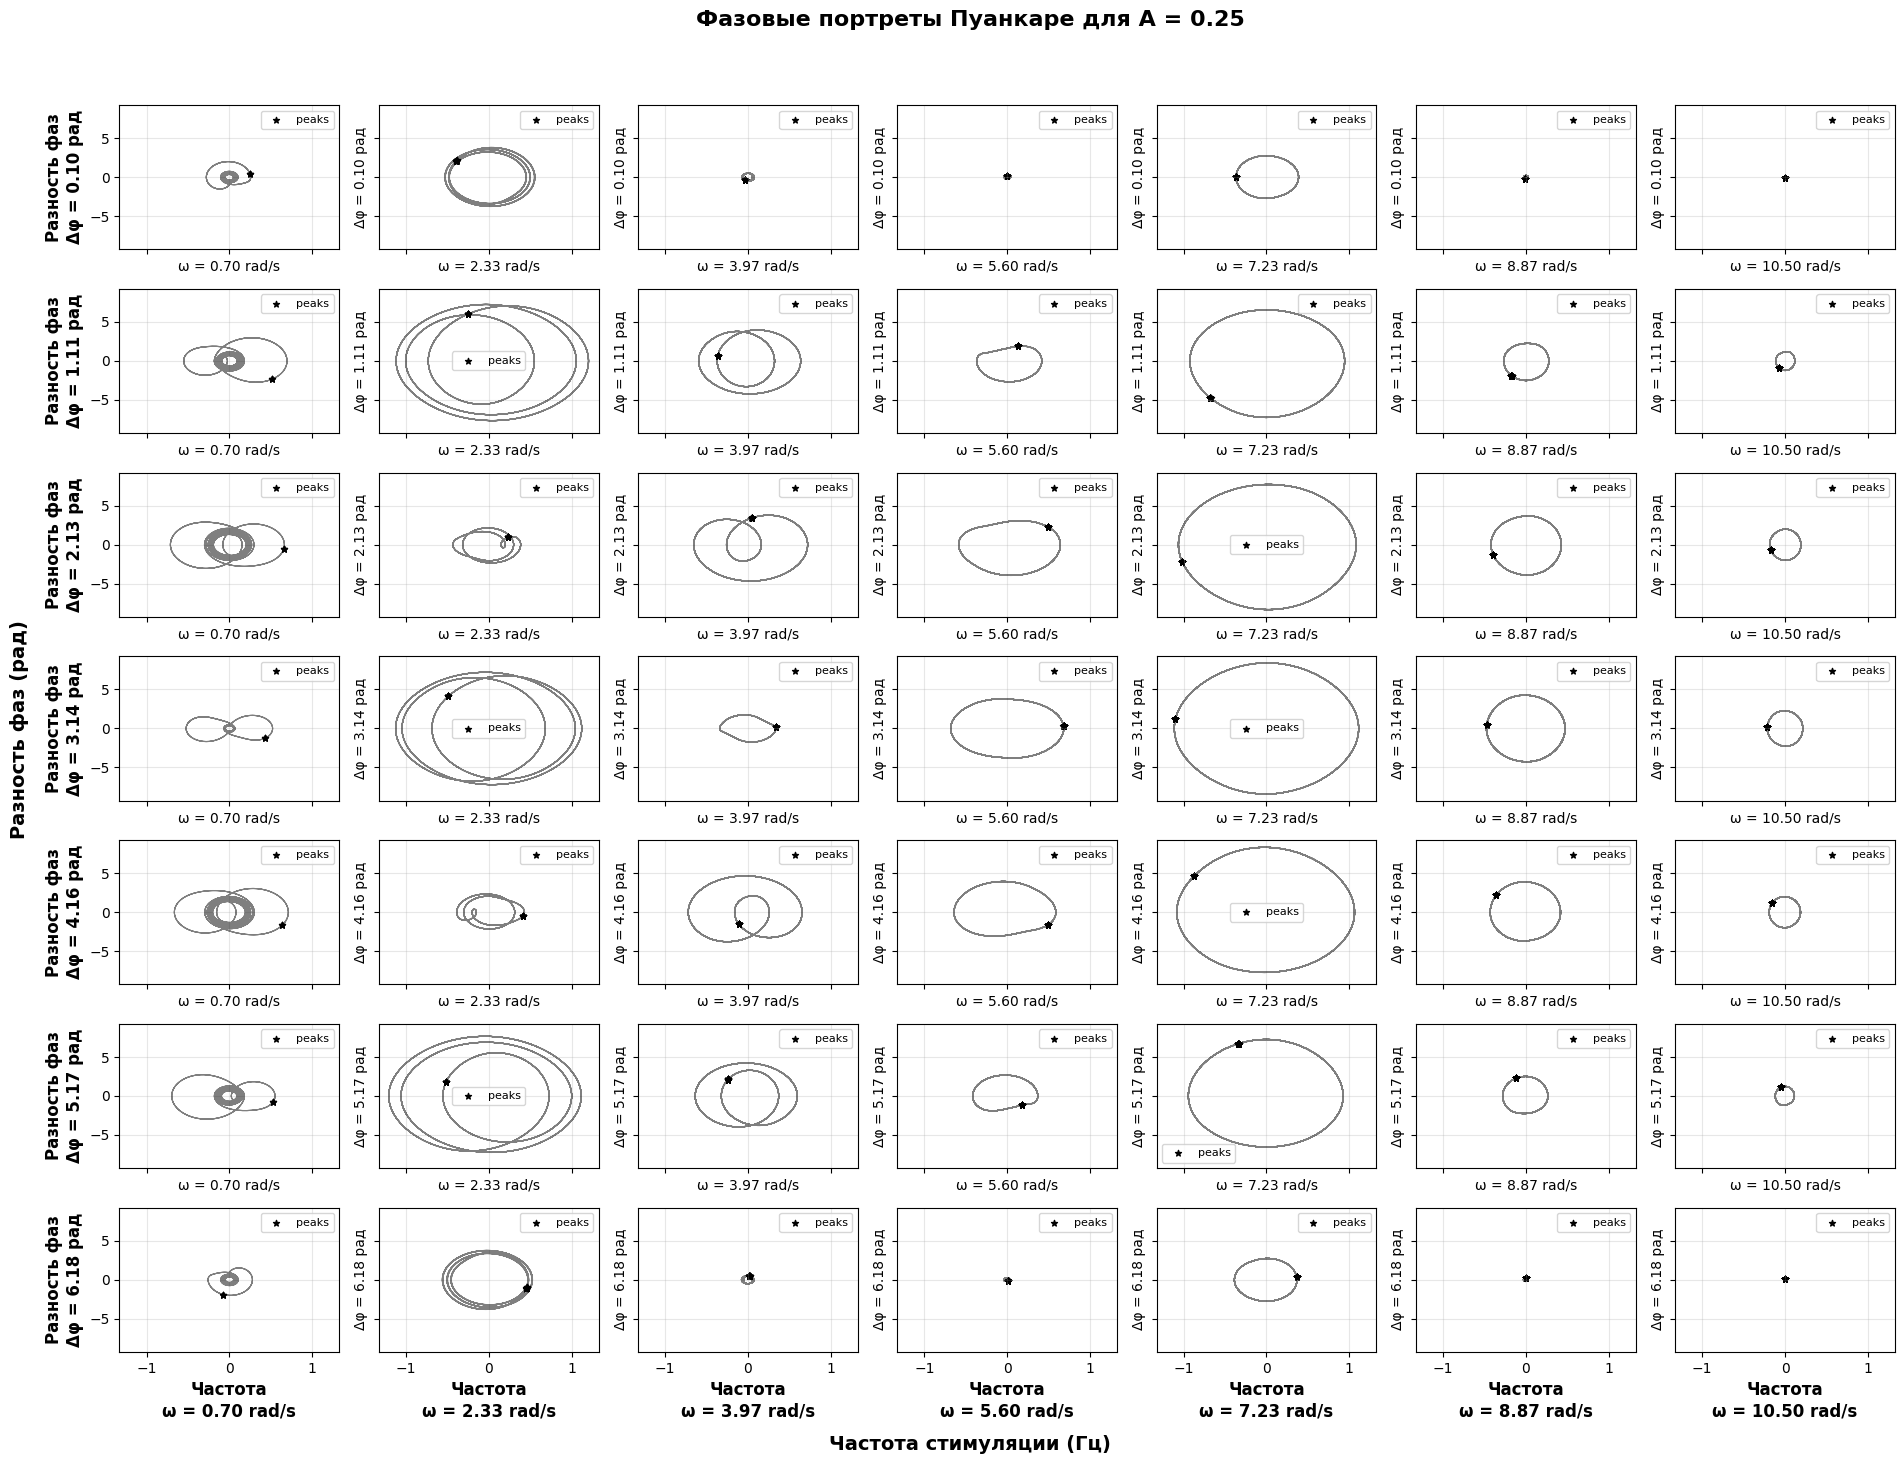

Фазовые портреты для A=0.3


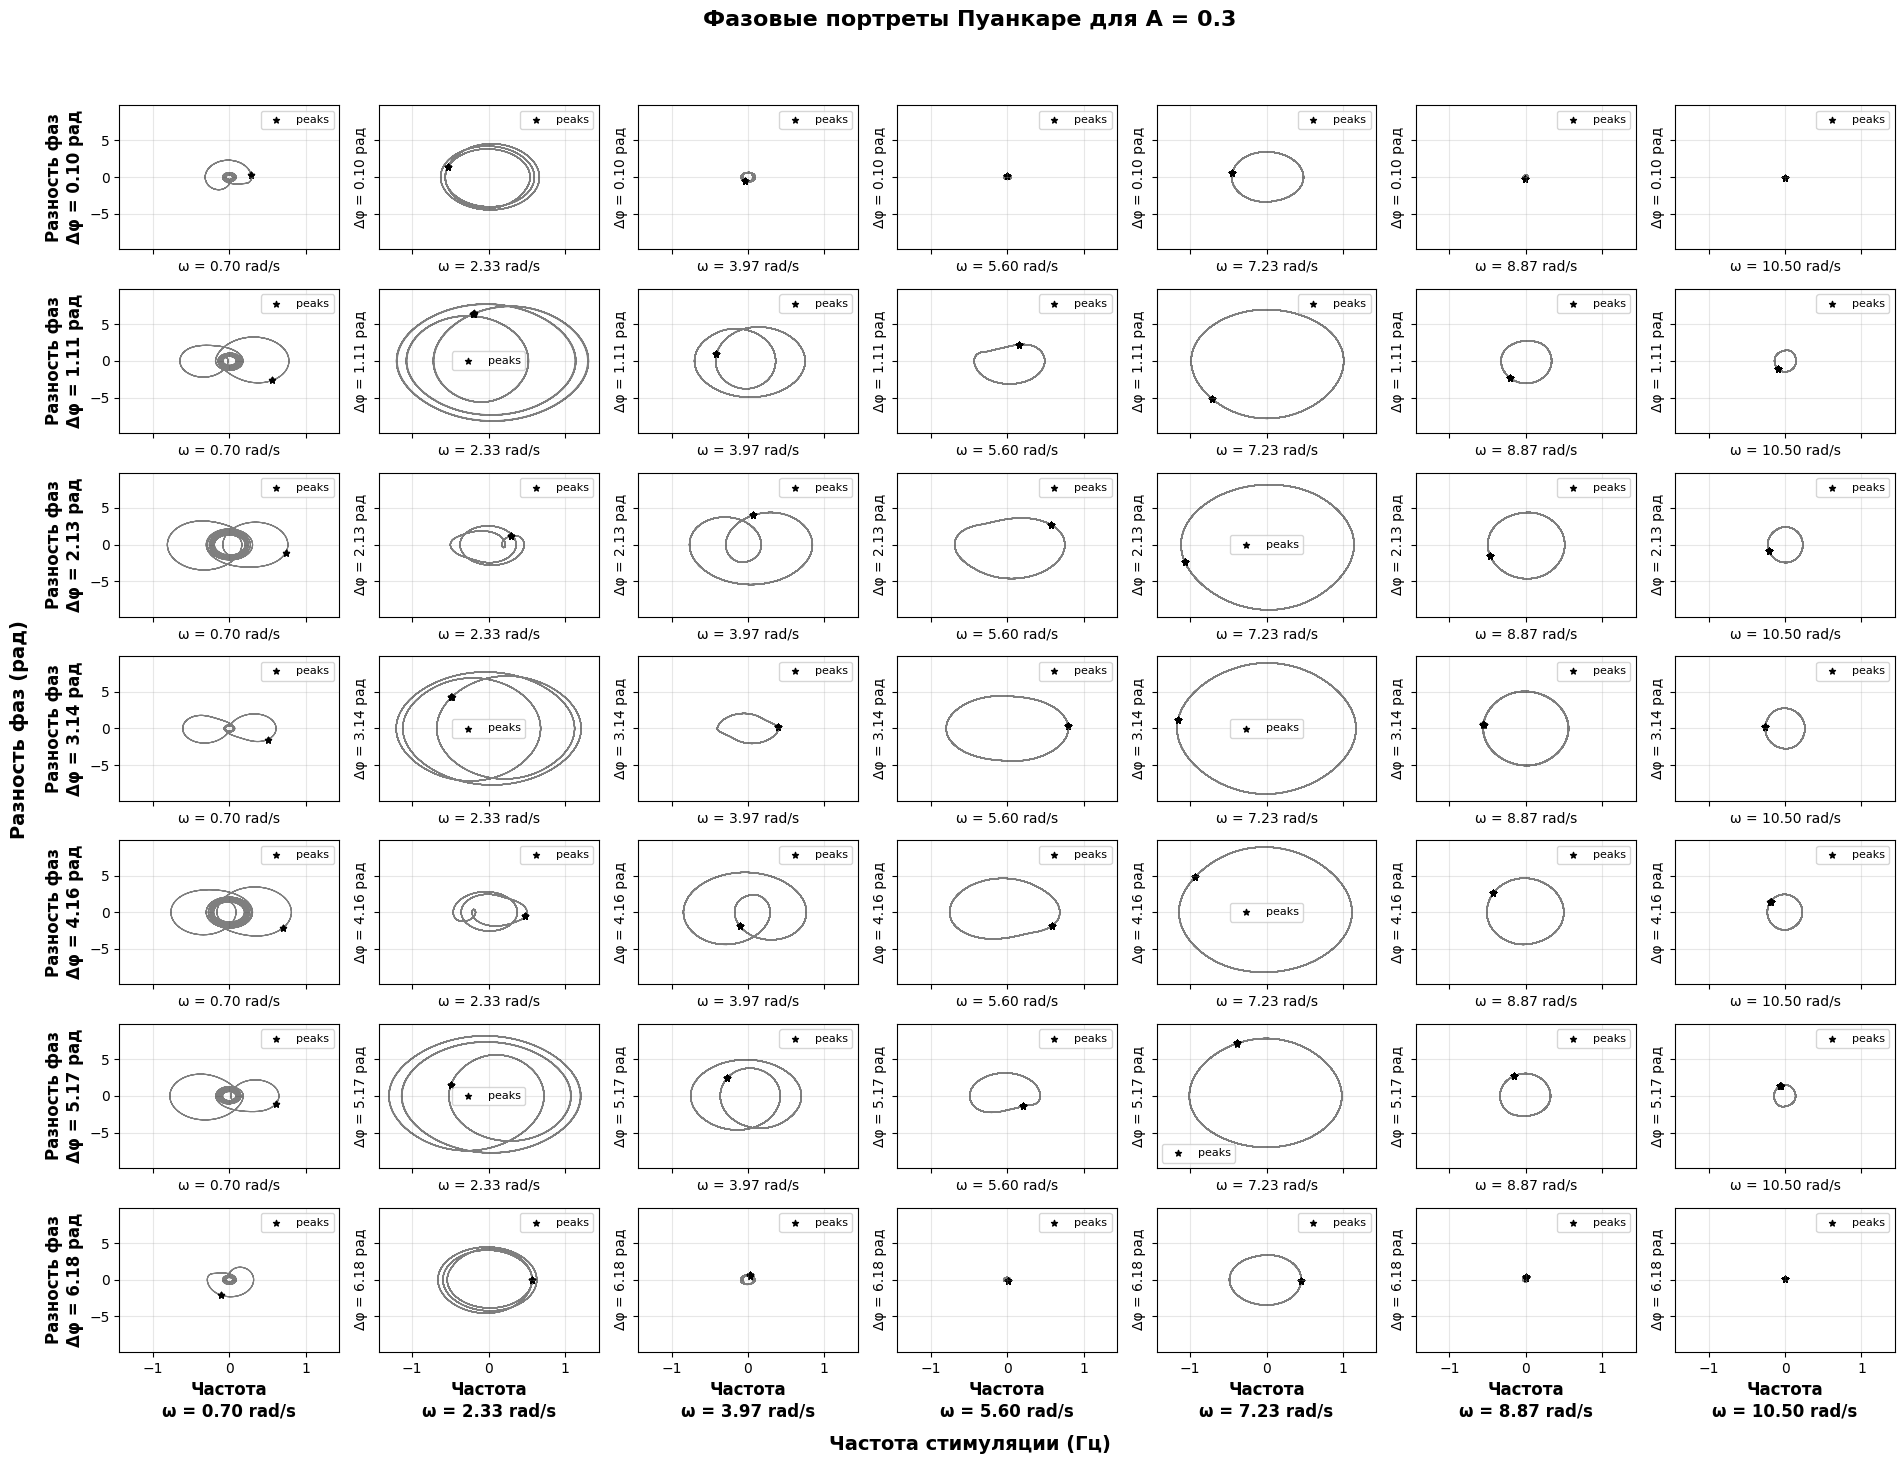

In [11]:
print(Ampls)
def plot_faceted_Puinkare(summary_tab, A, results_dir="results"):
    fig, axes = plt.subplots(len(DF), len(Freqs), figsize=(20, 15), sharex=True, sharey=True)

    fixed_A_tab = summary_tab[summary_tab['A'] == A]
    for i, df in enumerate(DF):
        for j, freq in enumerate(Freqs):
            row = fixed_A_tab[(fixed_A_tab['df'] == df) & (fixed_A_tab['w'] == freq)].iloc[0]
            data = np.load(os.path.join(results_dir, row['results_file']))
            T = data['T']
            mask = T > 70 * 1000
            Q = data['Q'][mask] - np.pi/2
            W = data['W'][mask]
            F_flex = data['F_flex'][mask]
            
            # Находим пики амлитуды мышцы сгибателя
            peaks, _ = find_peaks(F_flex)
            axes[i, j].plot(Q, W, 'k', lw=0.8, alpha=0.5)
            # Отражаем пики красными точками на проекциях фазового простраства (q, w)
            axes[i, j].scatter(Q[peaks], W[peaks], marker='*', c='k', label='peaks', s=20)
            
            # Улучшенные подписи осей
            if i == len(DF) - 1:
                axes[i, j].set_xlabel(f'Частота\nω = {freq:.2f} rad/s', fontsize=12, fontweight='bold')
            else:
                axes[i, j].set_xlabel(f'ω = {freq:.2f} rad/s', fontsize=10)
                
            if j == 0:
                axes[i, j].set_ylabel(f'Разность фаз\nΔφ = {df:.2f} рад', fontsize=12, fontweight='bold', rotation=90)
            else:
                axes[i, j].set_ylabel(f'Δφ = {df:.2f} рад', fontsize=10, rotation=90)
            
            # Добавляем сетку для лучшей читаемости
            axes[i, j].grid(True, alpha=0.3)
            axes[i, j].legend(fontsize=8)
    
    # Добавляем общие заголовки для осей
    fig.text(0.5, 0.02, 'Частота стимуляции (Гц)', ha='center', fontsize=14, fontweight='bold')
    fig.text(0.02, 0.5, 'Разность фаз (рад)', va='center', rotation=90, fontsize=14, fontweight='bold')
    
    # Общий заголовок для всей фигуры
    plt.suptitle(f'Фазовые портреты Пуанкаре для A = {A}', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout(rect=[0.03, 0.03, 0.97, 0.95])
    print(f'Фазовые портреты для A={A}')
    plt.show()
    
for A in Ampls:
     plot_faceted_Puinkare(summary_tab, A, results_dir="results")

**предложение**: проводить кластеризацию по форме(дисперсии) сечений пуанкаре

*Какие еще бывают характеристики сечений Пуанкаре???*


[0.1  0.15 0.2  0.25 0.3 ]
Фазовые портреты для A=0.1


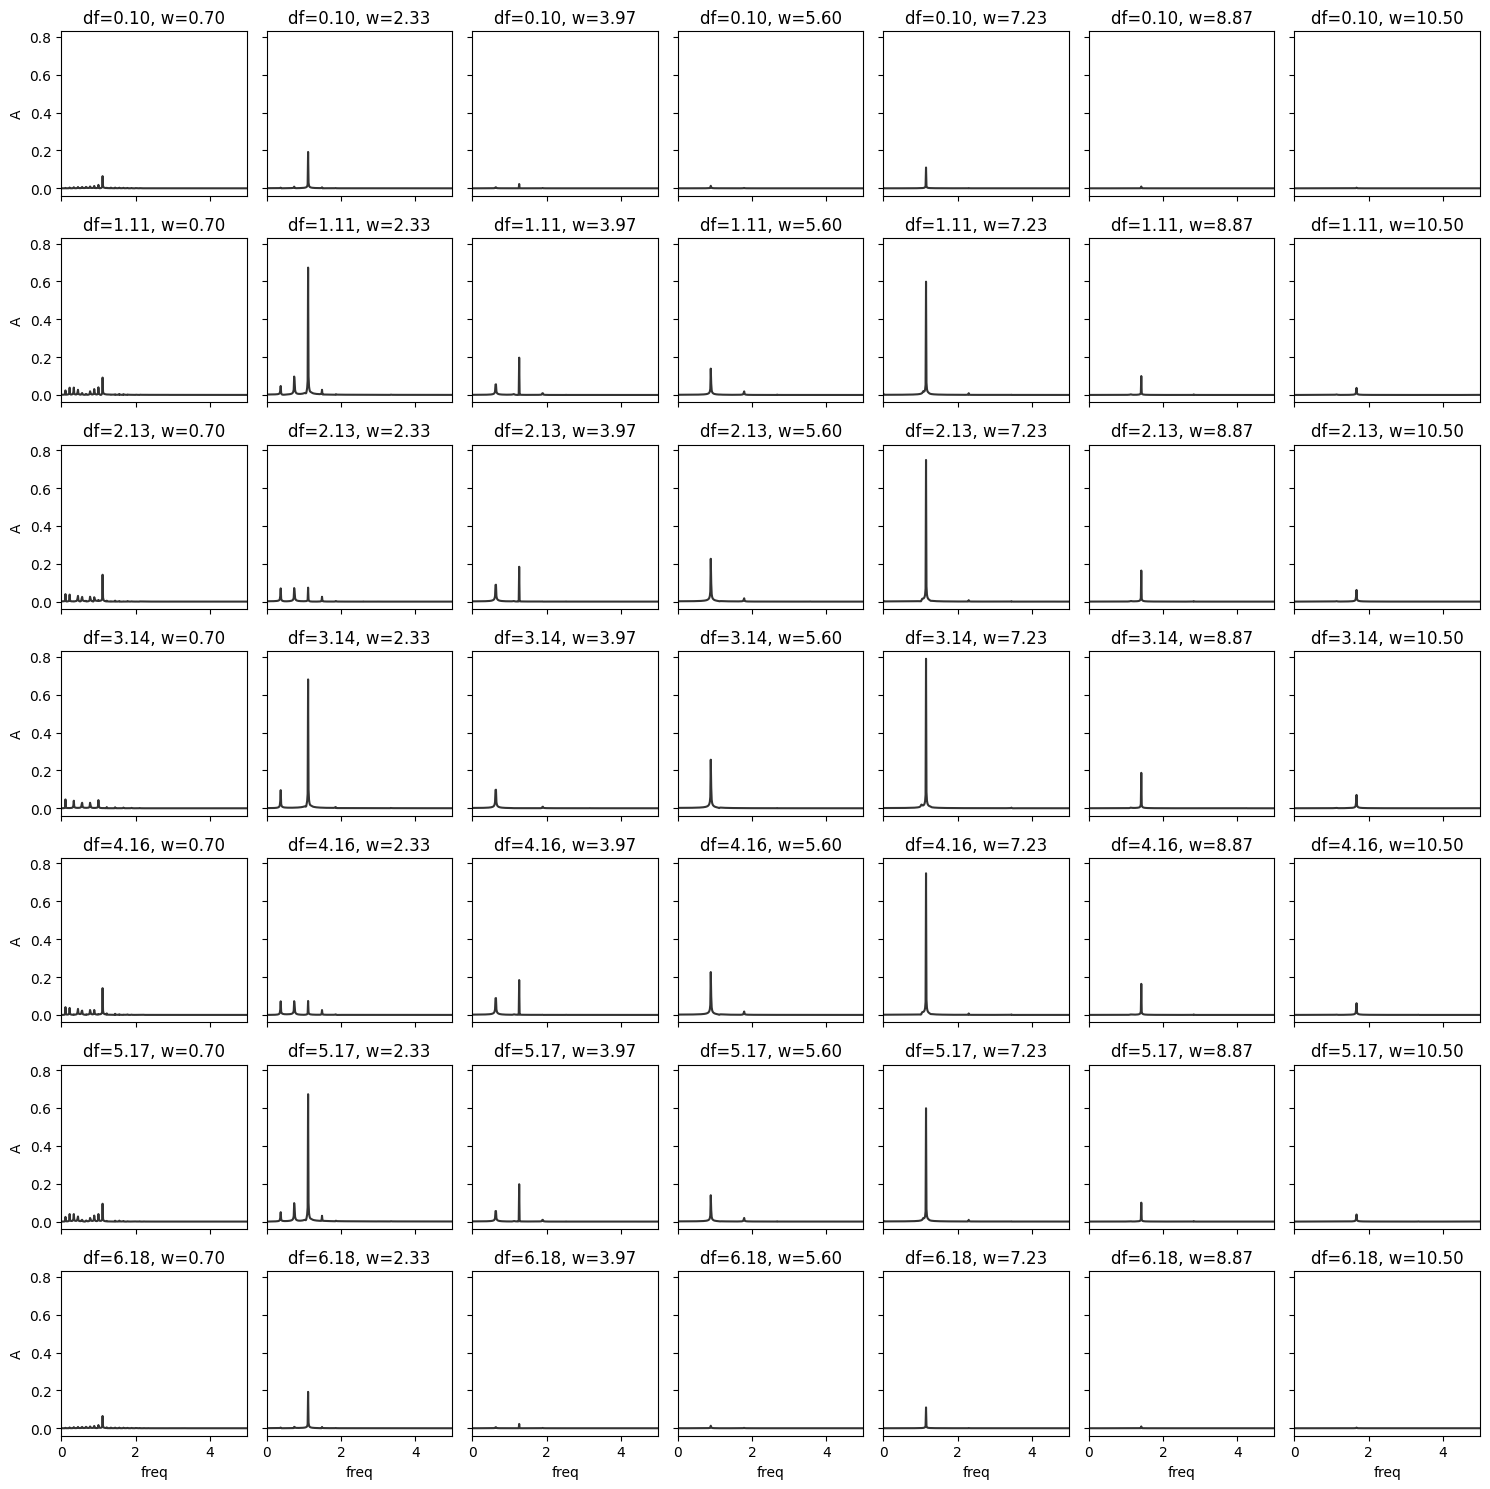

Фазовые портреты для A=0.15


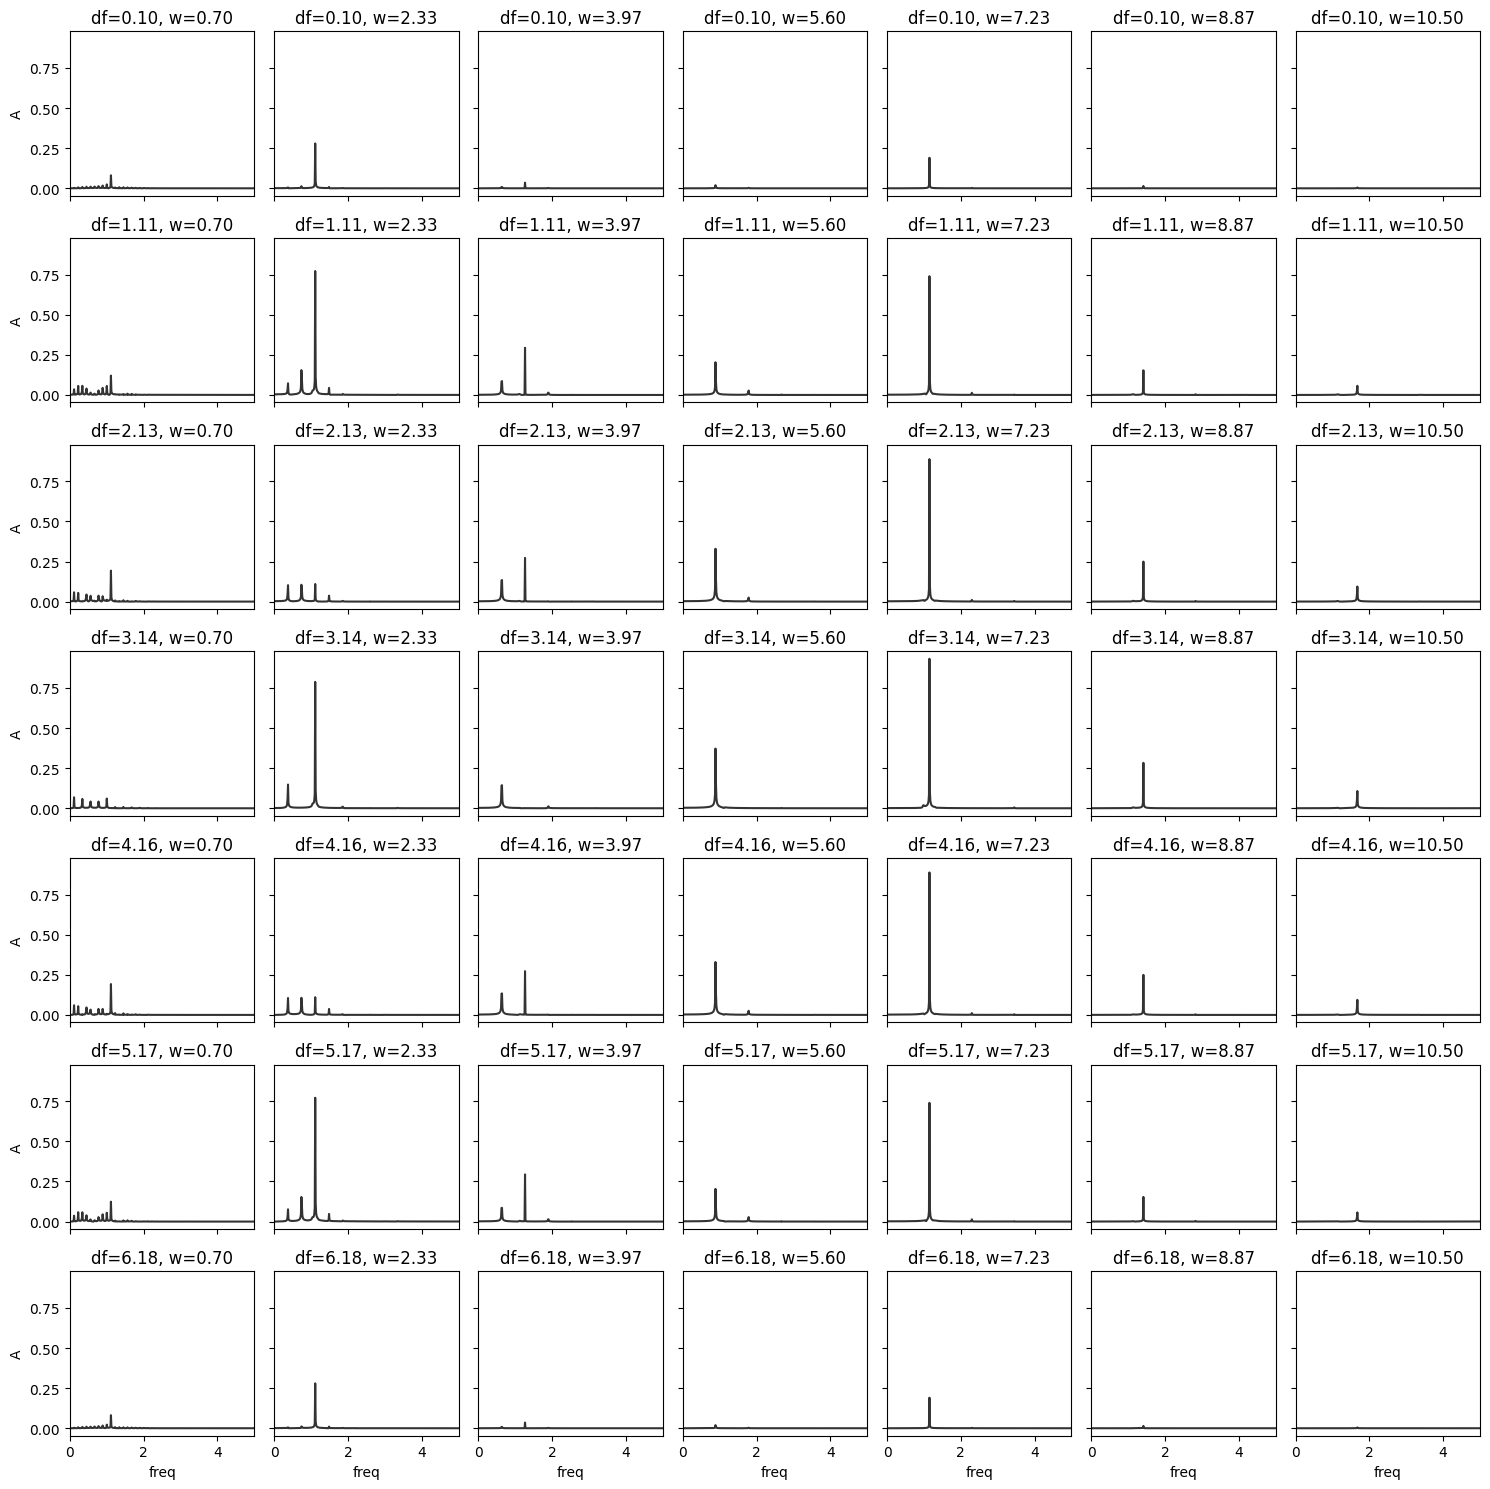

Фазовые портреты для A=0.2


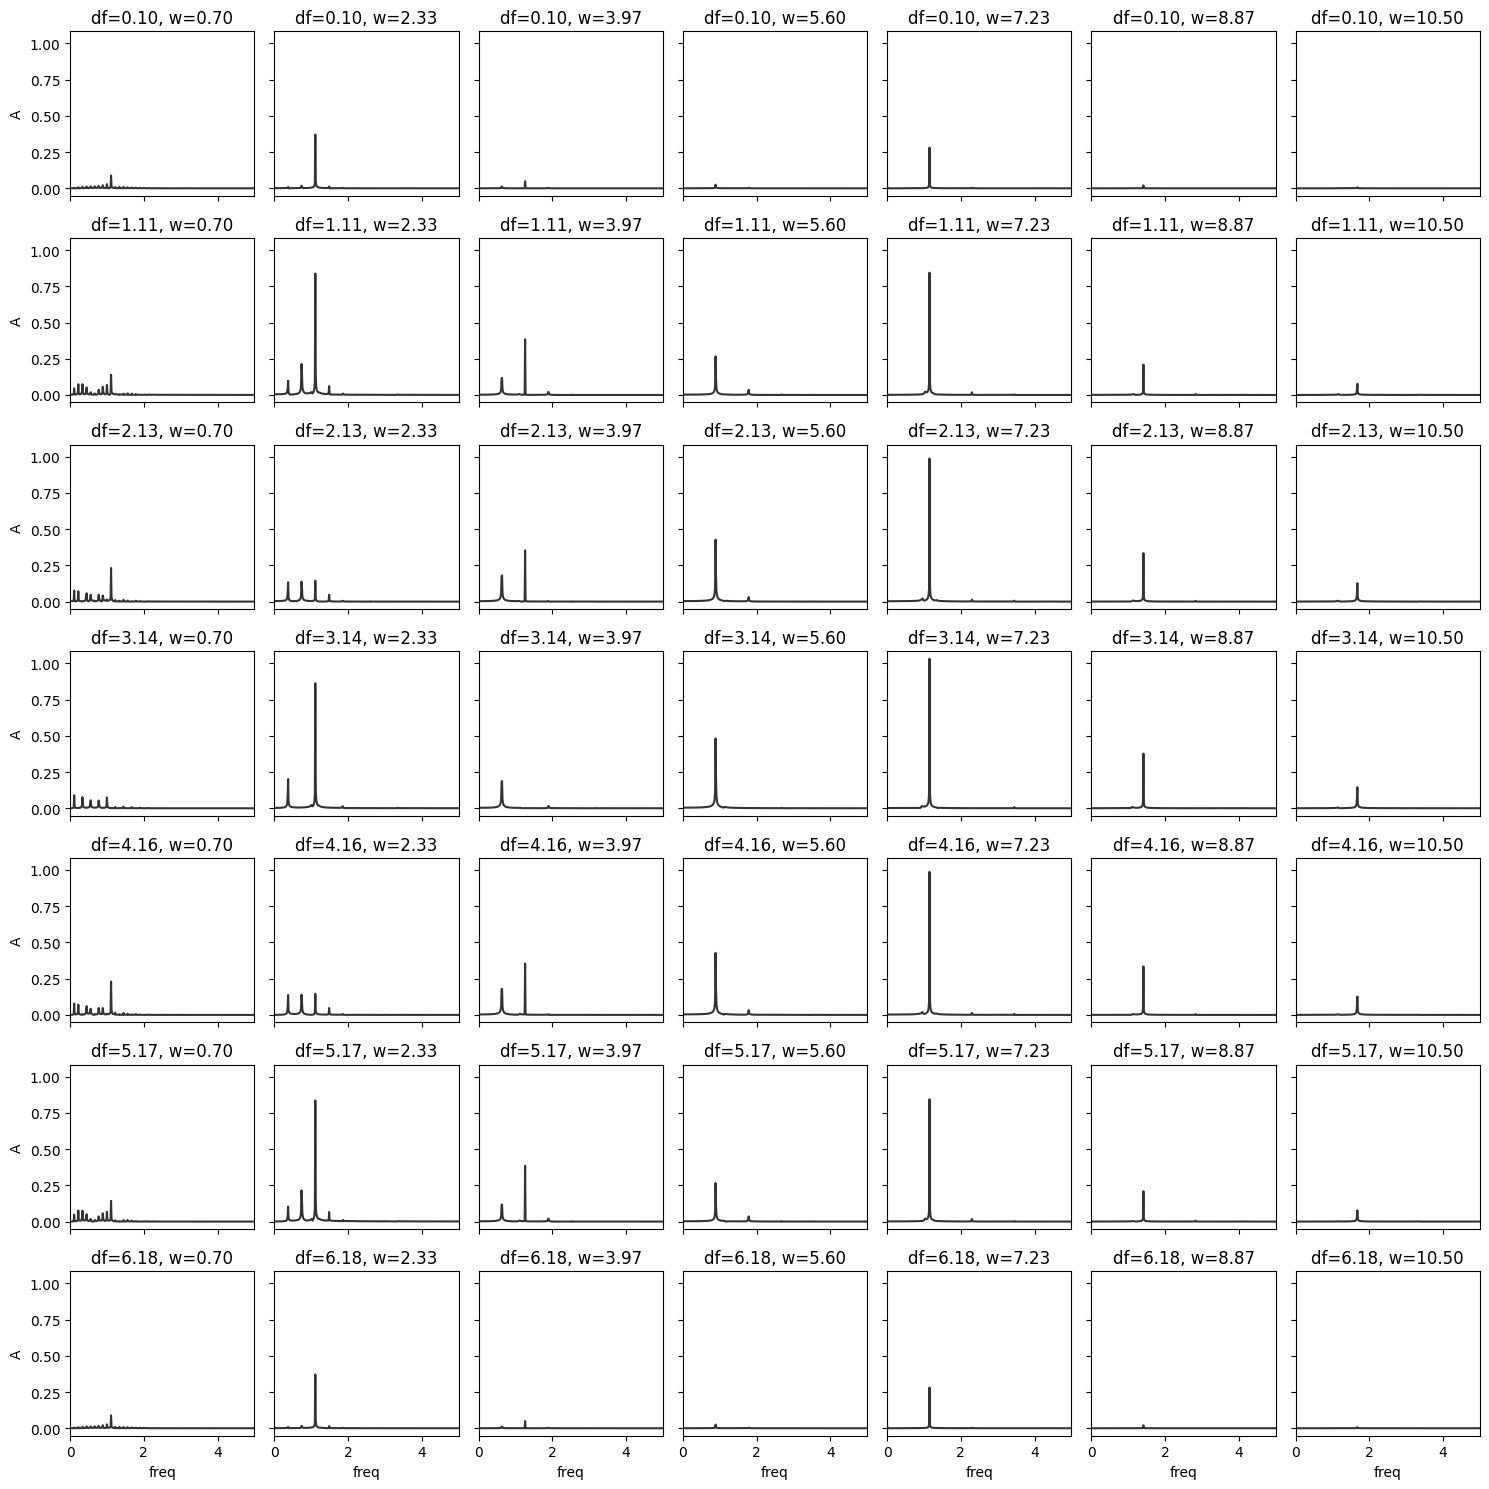

Фазовые портреты для A=0.25


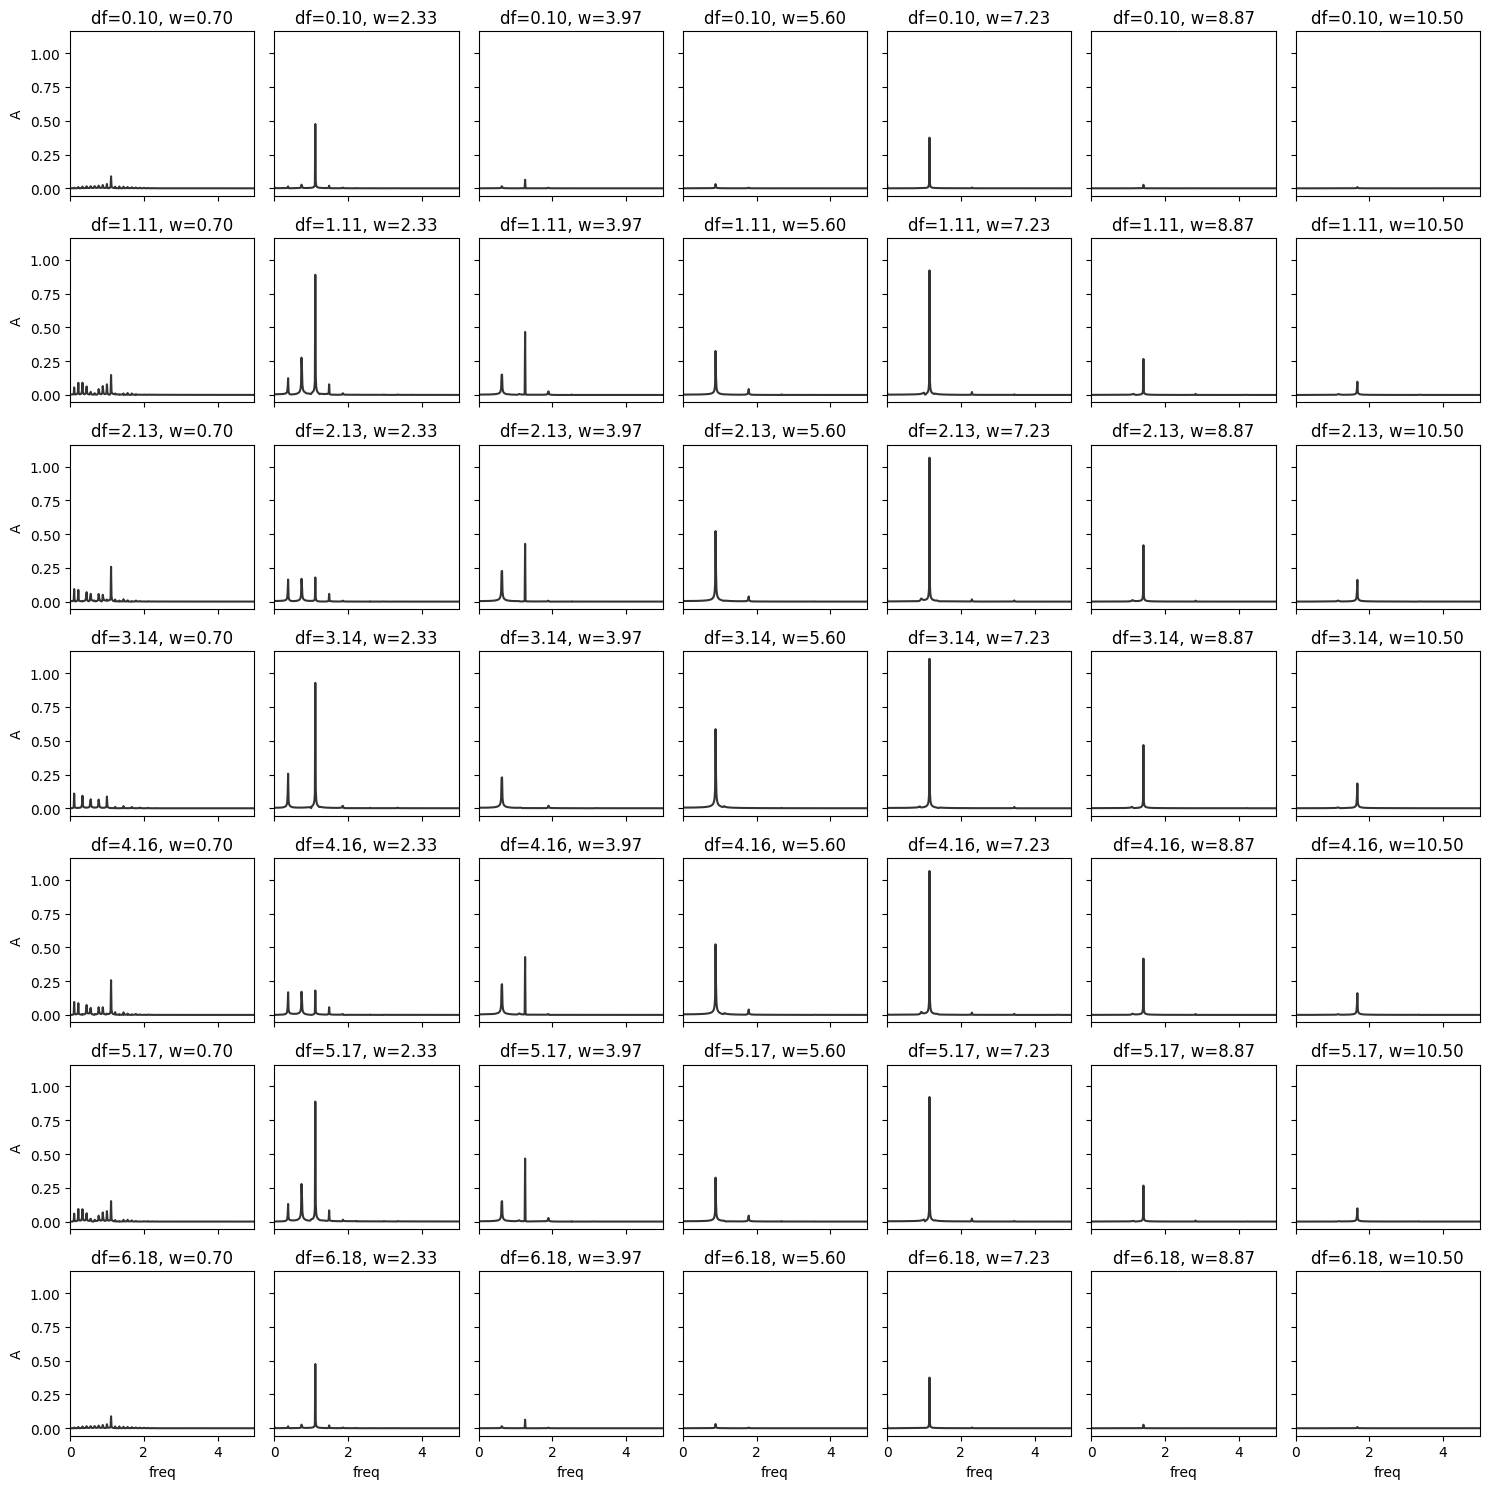

Фазовые портреты для A=0.3


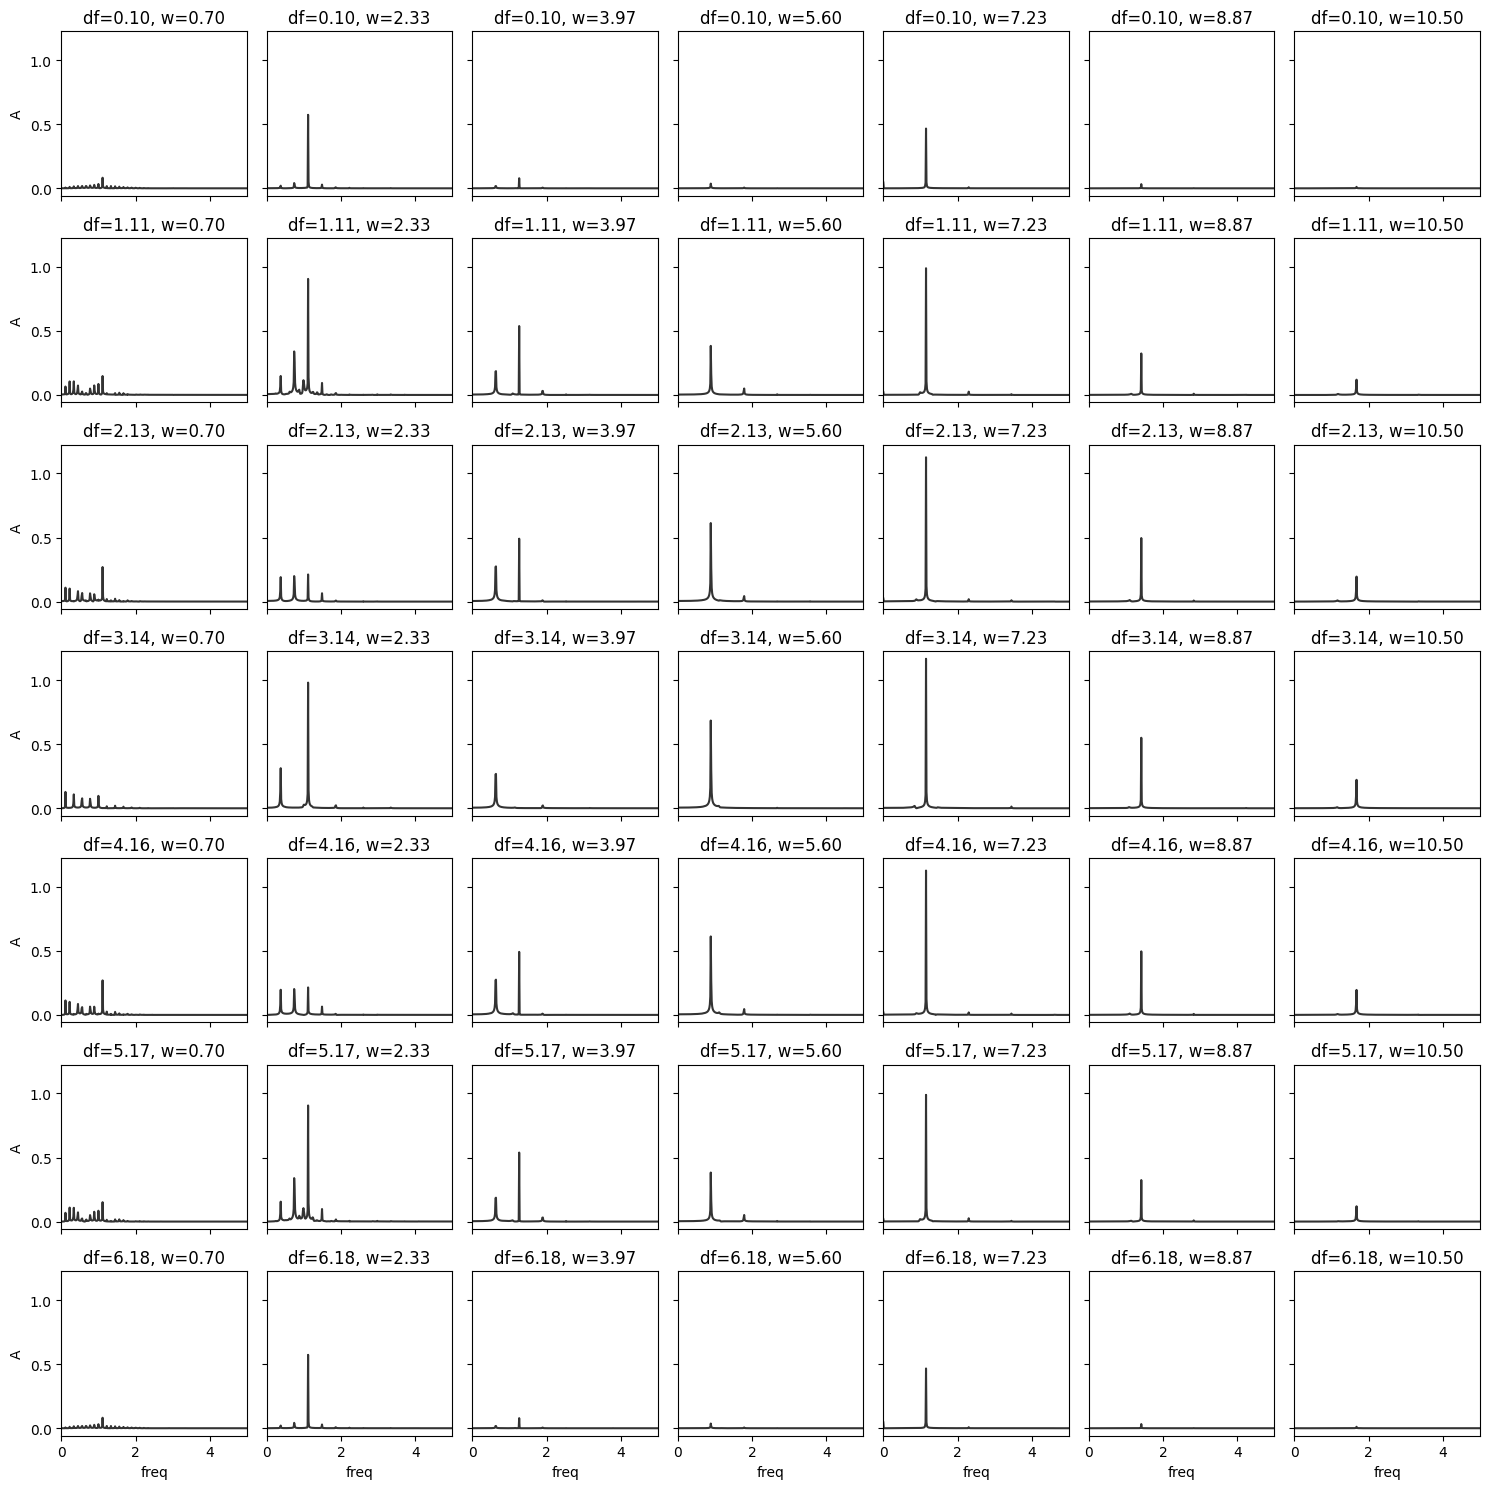

In [14]:
## Визуализация спектров колебаний
print(Ampls)
def plot_faceted_fft(summary_tab, A, results_dir="results"):
    fig, axes = plt.subplots(len(DF), len(Freqs), figsize=(15, 15), sharex=True, sharey=True)

    fixed_A_tab = summary_tab[summary_tab['A'] == A]
    for i, df in enumerate(DF):
        for j, freq in enumerate(Freqs):
            row=fixed_A_tab[(fixed_A_tab['df'] == df) & (fixed_A_tab['w'] == freq)].iloc[0]
            #print(row['results_file'])
            data = np.load(os.path.join(results_dir, row['results_file']))
            T = data['T']
            mask = T > 20 * 1000
            Q = data['Q'][mask]-np.pi/2
            W = data ['W'][mask]
            F_flex =data['F_flex'][mask]
            T = data['T']/1000

            # calc fft
            dt = T[1]-T[0]
            N = len(Q)
            yf = fft(Q)
            xf = fftfreq(N, dt)[:N//2]
            freqs = xf
            amplitudes = 2.0/N * np.abs(yf[0:N//2])
            
            axes[i, j].plot(freqs, amplitudes, 'k-', linewidth=1.5, alpha=0.8)
            axes[i, j].set_xlim(0, 5)
            axes[i, j].set_title(f'df={df:.2f}, w={freq:.2f}')
            if i == len(DF) - 1:
                axes[i, j].set_xlabel(r'freq')
            if j == 0:
                axes[i, j].set_ylabel(r'A')
    
    plt.tight_layout()
    print(f'Фазовые портреты для A={A}')
    plt.show()
    
for A in Ampls:
     plot_faceted_fft(summary_tab, A, results_dir="results")

**предложение:** проводить кластеризацию по 5ти частотам наибольшей амплитуды.

*как учитывать вклад собственной частоты???*

По формам спектров можно отделить квазипериодические режимы???


In [17]:
def spectral_analysis(Q, dt=0.01, n_peaks=5):
    """Спектральный анализ колебаний выделение частот с наибольшей амплитудой"""
    N = len(Q)
    
    # Вычисляем FFT
    yf = fft(Q)
    xf = fftfreq(N, dt)[:N//2]
    amplitudes = 2.0/N * np.abs(yf[0:N//2])
    
    # Находим пики в спектре
    peaks, _ = find_peaks(amplitudes, height=0.1 * np.max(amplitudes), distance=5)
    
    # Если нашли пики, берем n_peaks самых больших
    if len(peaks) > 0:
        # Сортируем пики по амплитуде
        peak_amplitudes = amplitudes[peaks]
        sorted_indices = np.argsort(peak_amplitudes)[::-1]
        
        # Берем не более n_peaks пиков
        n_to_take = min(n_peaks, len(peaks))
        top_indices = sorted_indices[:n_to_take]
        
        dominant_freqs = xf[peaks[top_indices]]
        dominant_amplitudes = peak_amplitudes[top_indices]
    else:
        # Если пиков не найдено, берем просто самые большие значения
        sorted_indices = np.argsort(amplitudes)[::-1]
        dominant_freqs = xf[sorted_indices[:n_peaks]]
        dominant_amplitudes = amplitudes[sorted_indices[:n_peaks]]
    
    return dominant_freqs, dominant_amplitudes, amplitudes

In [20]:
results_dir='results'
spectrum_tab = []
for _, row in summary_tab.iterrows():
    data = np.load(os.path.join(results_dir, row['results_file']))
    Q = data['Q'] - np.pi/2
    T = data['T']
    dt = (T[1]-T[0])/1000
    dom_freqs, dom_ampls, _ = spectral_analysis(Q, dt=dt, n_peaks=5)
    #print(dom_freqs)
    
    # Создаем списки с NaN для недостающих значений
    freqs_extended = list(dom_freqs) + [np.nan] * (5 - len(dom_freqs))
    ampls_extended = list(dom_ampls) + [np.nan] * (5 - len(dom_ampls))
    
    spectrum_row = {
        'A': row['A'],
        'w': row['w'],
        'df': row['df'],
        'f1': freqs_extended[0],
        'f2': freqs_extended[1],
        'f3': freqs_extended[2],
        'f4': freqs_extended[3],
        'f5': freqs_extended[4],
        'Aq1': ampls_extended[0],
        'Aq2': ampls_extended[1],
        'Aq3': ampls_extended[2],
        'Aq4': ampls_extended[3],
        'Aq5': ampls_extended[4]
    }
        
    spectrum_tab.append(spectrum_row)

In [22]:
spectrum_df = pd.DataFrame(spectrum_tab)
spectrum_df.head(25)
spectrum_df.to_csv('spectrum_metric.csv')

In [18]:
def plot_spectra_by_phase_difference(summary_tab, results_dir="results"):
    """Фасеточный график со спектрами для каждой разности фаз"""
    
    # Получаем уникальные значения разности фаз
    phase_diffs = sorted(summary_tab['df'].unique())
    n_phase_diffs = len(phase_diffs)
    
    # Создаем сетку графиков
    n_cols = 3
    n_rows = (n_phase_diffs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    # Проходим по каждой разности фаз
    for i, phase_diff in enumerate(phase_diffs):
        # Фильтруем данные по текущей разности фаз
        phase_subset = summary_tab[summary_tab['df'] == phase_diff]
        
        # Берем первую строку для примера (можно изменить логику выбора)
        if len(phase_subset) > 0:
            row = phase_subset.iloc[0]
            
            try:
                # Загружаем данные
                data = np.load(os.path.join(results_dir, row['results_file']))
                Q = data['Q']
                T = data['T'] / 1000
                
                # Предобработка сигнала
                Q = Q - np.pi/2
                
                # Вычисляем спектр
                dt = T[1] - T[0]
                freqs, ampls, full_spectrum = spectral_analysis(Q, dt=dt, n_peaks=10)
                
                # Строим спектр
                ax = axes[i]
                ax.plot(fftfreq(len(Q), dt)[:len(Q)//2], full_spectrum, 'b-', linewidth=1)
                
                # Добавляем вертикальные линии
                ax.axvline(row['w'], c='r', linestyle='--', alpha=0.8, label=f'ω = {row["w"]:.2f}')
                ax.axvline(7/6.28, c='g', linestyle='--', alpha=0.8, label='7/2π ≈ 1.11')
                
                # Подписываем пики
                for freq, amp in zip(freqs[:5], ampls[:5]):  # Топ-3 пика
                    ax.plot(freq, amp, 'ro', markersize=5)
                    ax.text(freq, amp * 0.9, f'{freq:.2f}', fontsize=8, ha='center')
                
                ax.set_xlabel('Частота (Hz)')
                ax.set_ylabel('Амплитуда')
                ax.set_title(f'Δφ = {phase_diff:.2f}, A = {row["A"]:.2f}, ω = {row["w"]:.2f}')
                ax.set_xlim(0, 5)  # Ограничиваем частотный диапазон
                ax.grid(True, alpha=0.3)
                ax.legend(fontsize=8)
                
            except Exception as e:
                print(f"Ошибка при обработке Δφ = {phase_diff}: {e}")
                axes[i].set_title(f'Ошибка: Δφ = {phase_diff}')
                axes[i].text(0.5, 0.5, 'Ошибка загрузки', ha='center', va='center')
        else:
            axes[i].set_title(f'Нет данных: Δφ = {phase_diff}')
    
    # Скрываем лишние оси
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Спектры колебаний для разных разностей фаз управляющего сигнала', 
                 fontsize=16, y=1.02)
    plt.show()

# Альтернативная версия с усреднением по всем данным для каждой разности фаз
def plot_averaged_spectra_by_phase(summary_tab, results_dir="results"):
    """Усредненные спектры для каждой разности фаз"""
    
    phase_diffs = sorted(summary_tab['df'].unique())
    n_phase_diffs = len(phase_diffs)
    
    n_cols = 3
    n_rows = (n_phase_diffs + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten()
    
    for i, phase_diff in enumerate(phase_diffs):
        phase_subset = summary_tab[summary_tab['df'] == phase_diff]
        
        all_spectra = []
        freqs = None
        
        # Собираем спектры для всех данных с данной разностью фаз
        for _, row in phase_subset.iterrows():
            try:
                data = np.load(os.path.join(results_dir, row['results_file']))
                Q = data['Q'] - np.pi/2
                T = data['T'] / 1000
                dt = T[1] - T[0]
                
                # Вычисляем спектр
                N = len(Q)
                yf = fft(Q)
                xf = fftfreq(N, dt)[:N//2]
                amplitudes = 2.0/N * np.abs(yf[0:N//2])
                
                if freqs is None:
                    freqs = xf
                all_spectra.append(amplitudes)
                
            except Exception as e:
                print(f"Ошибка в файле {row['results_file']}: {e}")
                continue
        
        if all_spectra:
            # Усредняем спектры
            avg_spectrum = np.mean(all_spectra, axis=0)
            
            # Строим усредненный спектр
            ax = axes[i]
            ax.plot(freqs, avg_spectrum, 'b-', linewidth=1.5, alpha=0.8)
            
            # Добавляем характерные частоты
            if len(phase_subset) > 0:
                sample_row = phase_subset.iloc[0]
                ax.axvline(sample_row['w'], c='r', linestyle='--', alpha=0.8, 
                          label=f'ω = {sample_row["w"]:.2f}')
                ax.axvline(7/6.28, c='g', linestyle='--', alpha=0.8, label='7/2π ≈ 1.11')
            
            ax.set_xlabel('Частота (Hz)')
            ax.set_ylabel('Амплитуда')
            ax.set_title(f'Усредненный спектр: Δφ = {phase_diff:.2f}\n'
                        f'N = {len(all_spectra)} спектров')
            ax.set_xlim(0, 5)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
        else:
            axes[i].set_title(f'Нет данных: Δφ = {phase_diff}')
            axes[i].text(0.5, 0.5, 'Нет данных', ha='center', va='center')
    
    # Скрываем лишние оси
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.suptitle('Усредненные спектры колебаний для разных разностей фаз', 
                 fontsize=16, y=1.02)
    plt.show()

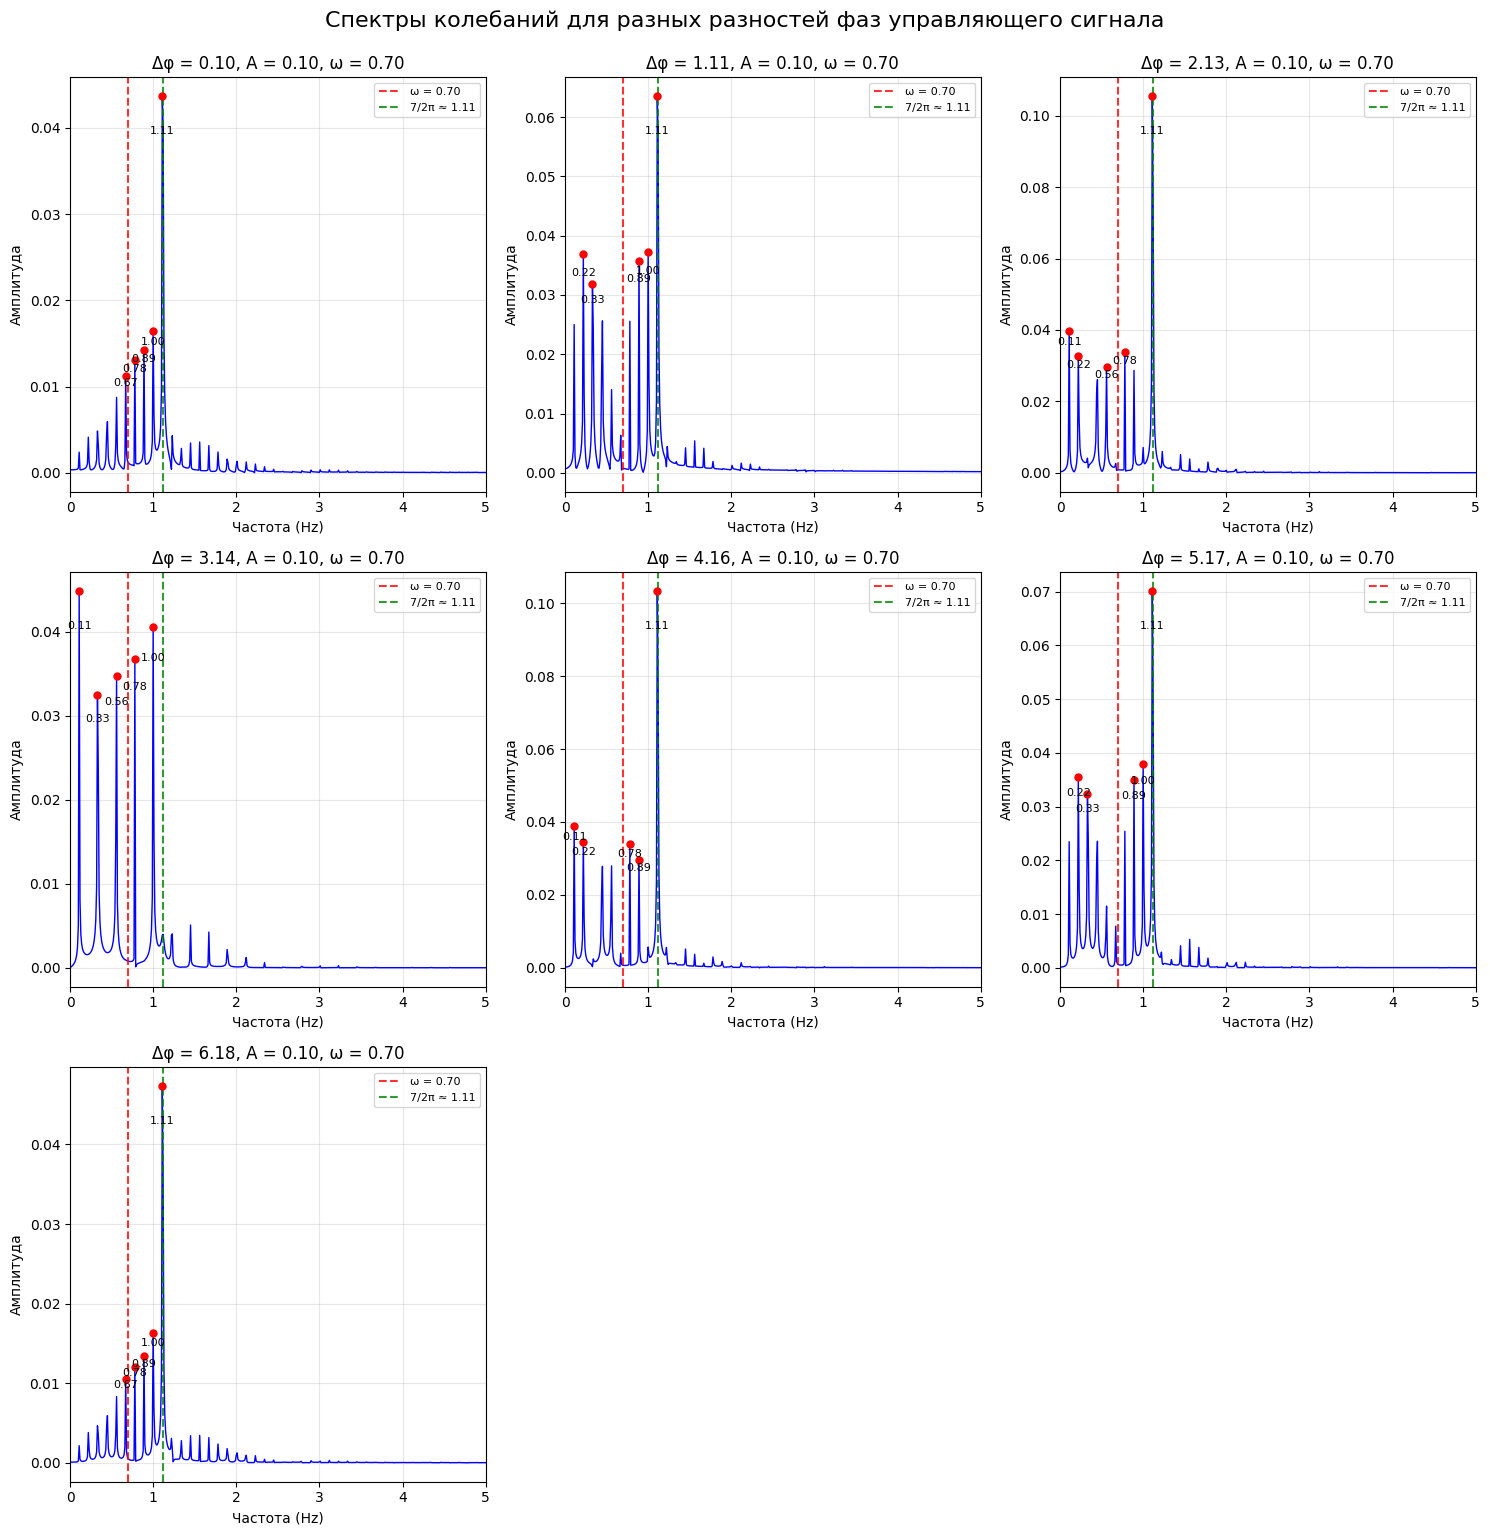

In [19]:
    # Загрузите ваш summary_tab
    
    # Вариант 1: Индивидуальные спектры
    plot_spectra_by_phase_difference(summary_tab, results_dir="results")
    

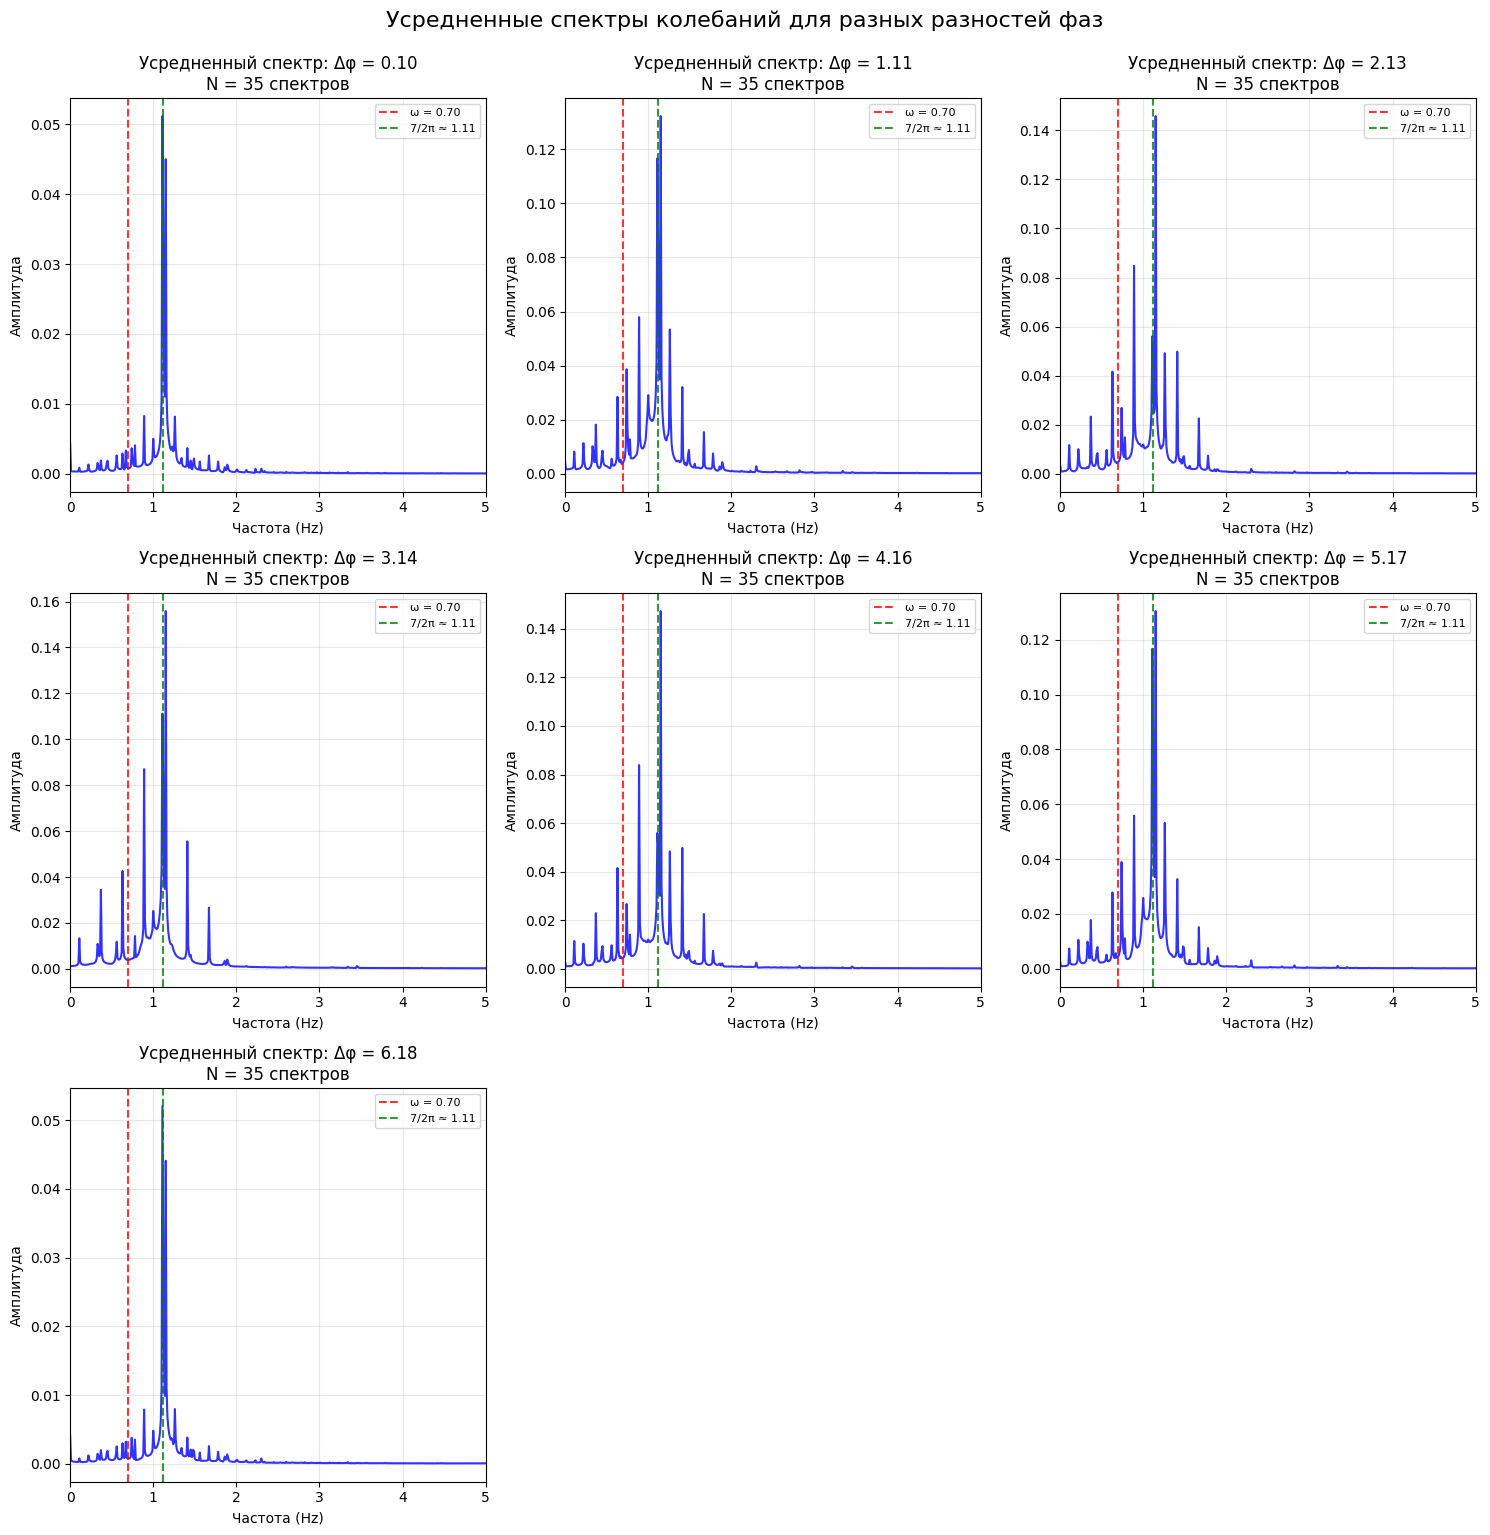

In [24]:
    # Вариант 2: Усредненные спектры
    plot_averaged_spectra_by_phase(summary_tab, results_dir="results")
    

# Аппробация метода показателя ляпунова

In [60]:
from nolds import sampen, dfa, lyap_r

def nonlinear_metrics(Q):
    metrics = {}
    
    try:
        # Энтропия выборки (мера регулярности)
        %time metrics['sample_entropy'] = sampen(Q)
        
        # Детрендированная флуктуационный анализ
        %time metrics['dfa_alpha'] = dfa(Q)
        
        # Показатель Ляпунова (приближенный)
        %time metrics['lyapunov_exp'] = lyap_r(Q, min_tsep=10, tau=1)
        
    except:
        metrics['sample_entropy'] = np.nan
        metrics['dfa_alpha'] = np.nan
        metrics['lyapunov_exp'] = np.nan
    
    return metrics

In [61]:
row = summary_tab.iloc[0]
data = np.load(os.path.join(results_dir, row['results_file']))
Q = data['Q'] - np.pi/2
nonlinear_metrics(Q)

/home/nickolai/myvenv/lib/python3.12/site-packages/nolds/measures.py:402: SyntaxWarning: invalid escape sequence '\|'
  """
/home/nickolai/myvenv/lib/python3.12/site-packages/nolds/measures.py:1402: SyntaxWarning: invalid escape sequence '\|'
  """


KeyboardInterrupt: 

KeyboardInterrupt: 

KeyboardInterrupt: 

{}